In [1]:
import os
import joblib

from sklearn.model_selection import RepeatedKFold
from sklearn.metrics import hamming_loss
from scipy.stats import gaussian_kde

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch

from utils import *

In [2]:
cwd = os.getcwd()

# datasets = ['Chowell_train', 'Chowell_test', 'MSK1', 'MSK2', 'Shim_NSCLC',
#             'Kato_panCancer', 'Vanguri_NSCLC', 'Ravi_NSCLC', 'Pradat_panCancer']
datasets = ['Chowell_train', 'Chowell_test', 'MSK1', 'MSK2',
            'Shim_NSCLC', 'Kato_panCancer']
datasets_ids = list(range(1, len(datasets) + 1))

datasets_dict = {
    'Chowell_train': 'Cho1',
    'Chowell_test': 'Cho2',
    'MSK1': 'MSK1',
    'MSK2': 'MSK2',
    'Shim_NSCLC': 'Shim',
    'Kato_panCancer': 'Kato',
    'Vanguri_NSCLC': 'Vang',
    'Ravi_NSCLC': 'Ravi',
    'Pradat_panCancer': 'Prad'
}

n_datasets = len(datasets_ids)

# Accuracies

## Comparison accuracies on Chowell_train

In [3]:
# plt.rc('font', family='serif', serif='Computer Modern', size=16)
# plt.rc('text', usetex=True)

plt.rc('font', family='serif', serif='Times', size=16)
plt.rc('text', usetex=True)

# Font sizes
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 15   # Title font size
plt.rcParams['axes.labelsize'] = 12   # Axis label font size
plt.rcParams['xtick.labelsize'] = 12  # X-axis tick label font size
plt.rcParams['ytick.labelsize'] = 12  # Y-axis tick label font size
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['legend.title_fontsize'] = 10

# Lines
plt.rcParams['axes.linewidth'] = 0.5  # Default is usually 1.0

# Ticks
plt.rcParams['xtick.major.width'] = 0.5   # Width of major ticks on X-axis
plt.rcParams['ytick.major.width'] = 0.5   # Width of major ticks on Y-axis
plt.rcParams['xtick.minor.width'] = 0.4   # Width of minor ticks on X-axis
plt.rcParams['ytick.minor.width'] = 0.4   # Width of minor ticks on Y-axis

plt.rcParams['xtick.major.size'] = 4
plt.rcParams['ytick.major.size'] = 4
plt.rcParams['xtick.minor.size'] = 2
plt.rcParams['ytick.minor.size'] = 2


figures_dir = os.path.join(cwd, 'figures')
os.makedirs(figures_dir, exist_ok=True)

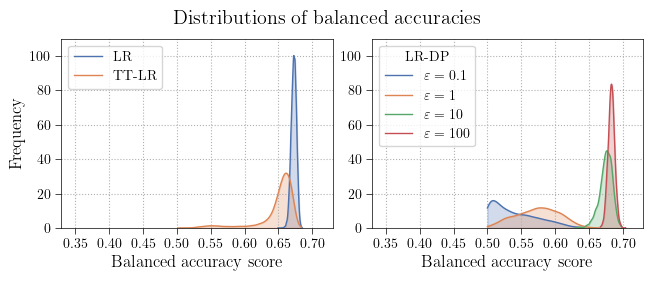

In [ ]:
# vanilla
scaler_type = 'standard'
model_type = 'vanilla'

palette = sns.color_palette('deep')
colors = palette#[0], palette[1], palette[2], palette
# colors = plt.cm.tab10.colors

model_names_dict = {
    'lr': 'LR',
    'tt_lr': 'TT-LR'
}

fig, ax = plt.subplots(1, 2, figsize=(6.5, 2.75))


# lr
model_name = 'lr'
data_dir = os.path.join(cwd, 'results', 'datasets', 'lr',
                        scaler_type, model_type, 'params_multilabel.pt')
data = torch.load(data_dir, weights_only=True)

mask = data['labels'][:, 0] == 1
accs = data['bal_accs'][mask]

data_plot = accs[:, -1].numpy()

kde = gaussian_kde(data_plot)  # fits a smooth PDF
x = np.linspace(data_plot.min(), data_plot.max(), 100)
y = kde(x)

ax[0].plot(x, y,
            linewidth=1.,
            color=colors[0],
            label=model_names_dict[model_name])
ax[0].fill_between(x, y,
                    alpha=0.25,
                    color=colors[0])  # shadow below curve

# tt_lr
model_name = 'tt_lr'
data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                        scaler_type, model_type, 'params_multilabel_6.pt')
data = torch.load(data_dir, weights_only=True)

mask = data['labels'][:, 0] == 1
accs = data['bal_accs'][mask]

data_plot = accs[:, -1].numpy()

kde = gaussian_kde(data_plot)  # fits a smooth PDF
x = np.linspace(data_plot.min(), data_plot.max(), 100)
y = kde(x)

ax[0].plot(x, y,
            linewidth=1.,
            color=colors[1],
            label=model_names_dict[model_name])
ax[0].fill_between(x, y,
                    alpha=0.25,
                    color=colors[1])  # shadow below curve

ax[0].set_xlabel('Balanced accuracy score')
ax[0].set_ylabel('Frequency')
ax[0].set_ylim(0, 110)
ax[0].set_xlim(0.33, 0.73)
ax[0].set_xticks(torch.arange(0.35, 0.75, 0.05))
ax[0].grid(True, zorder=-1, linestyle=':')

ax[0].legend()


# lr_dp
epsilon_list = [0.1, 1.0, 10.0, 100.0]
epsilon_dict = {
    0.1   : '0.1',
    1.0   : '1',
    10.0  : '10',
    100.0 : '100'}
for i, epsilon in enumerate(epsilon_list):
    data_dir = os.path.join(cwd, 'results', 'datasets', 'lr_dp',
                            scaler_type, model_type,
                            f'params_multilabel_{epsilon}.pt')
    data = torch.load(data_dir, weights_only=True)
    
    mask = data['labels'][:, 0] == 1
    accs = data['bal_accs'][mask]
    
    data_plot = accs[:, 0].numpy()
    
    kde = gaussian_kde(data_plot)  # fits a smooth PDF
    x = np.linspace(data_plot.min(), data_plot.max(), 100)
    y = kde(x)
    
    ax[1].plot(x, y,
               linewidth=1.,
               color=colors[i],
               label=fr'$\varepsilon={epsilon_dict[epsilon]}$')
    ax[1].fill_between(x, y,
                       alpha=0.25,
                       color=colors[i])  # shadow below curve

ax[1].set_xlabel('Balanced accuracy score')
ax[1].set_ylim(0, 110)
ax[1].set_xlim(0.33, 0.73)
ax[1].set_xticks(torch.arange(0.35, 0.75, 0.05))
ax[1].grid(True, zorder=-1, linestyle=':')

ax[1].legend(title='LR-DP')

fig.suptitle('Distributions of balanced accuracies')

# Show plot
plt.tight_layout(pad=0.5)
# plt.savefig(os.path.join(figures_dir, 'accuracies_chowell_train.pdf'),
#             bbox_inches='tight')
plt.show()

## Models trained on each dataset

In [13]:
scaler_type = 'standard'

for model_name in ['lr']:
    for model_type in ['vanilla', 'average']:
        print(f'{model_name.upper()} | {model_type.upper()}', end=' | ')
        data_dir = os.path.join(
            cwd, 'results', 'datasets', model_name,
            scaler_type, model_type, 'params_multilabel.pt'
        )
        data = torch.load(data_dir, weights_only=True)

        n_datasets = len(datasets_ids)
        for train_did in range(n_datasets):
            cond_vector = torch.zeros(n_datasets)
            cond_vector[train_did] = 1
            mask = (data['labels'] == cond_vector).all(dim=1).bool()

            accs = data['bal_accs'][mask, train_did]
            aucs = data['auc_scores'][mask, train_did]
            
            print(f'{accs.median().item():.2f}, {aucs.median().item():.2f}', end=' | ')
        print()

LR | VANILLA | 0.68, 0.74 | 0.71, 0.77 | 0.69, 0.72 | 0.64, 0.63 | 0.65, 0.65 | 0.77, 0.77 | 
LR | AVERAGE | 0.68, 0.74 | 0.70, 0.78 | 0.69, 0.72 | 0.67, 0.64 | 0.65, 0.65 | 0.87, 0.85 | 


In [15]:
scaler_type = 'standard'

for model_name in ['tt_lr']:
    for model_type in ['vanilla']:
        print(f'{model_name.upper()} | {model_type.upper()}', end=' | ')
        data_dir = os.path.join(
            cwd, 'results', 'datasets', model_name,
            scaler_type, model_type, 'params_multilabel_6.pt'
        )
        data = torch.load(data_dir, weights_only=True)

        n_datasets = len(datasets_ids)
        for train_did in range(n_datasets):
            cond_vector = torch.zeros(n_datasets)
            cond_vector[train_did] = 1
            mask = (data['labels'] == cond_vector).all(dim=1).bool()

            accs = data['bal_accs'][mask, train_did]
            aucs = data['auc_scores'][mask, train_did]
            
            print(f'{accs.median().item():.2f}, {aucs.median().item():.2f}', end=' | ')
        print()

TT_LR | VANILLA | 0.67, 0.72 | 0.69, 0.75 | 0.67, 0.69 | 0.63, 0.62 | 0.64, 0.64 | 0.77, 0.76 | 


In [19]:
for model_name in ['nn']:
    print(f'{model_name.upper()}', end=' | ')
    data_dir = os.path.join(
        cwd, 'results', 'datasets', model_name, 'params_multilabel.pt')
    data = torch.load(data_dir, weights_only=True)
    
    n_datasets = len(datasets_ids)
    for train_did in range(n_datasets):
        cond_vector = torch.zeros(n_datasets)
        cond_vector[train_did] = 1
        mask = (data['labels'] == cond_vector).all(dim=1).bool()

        accs = data['bal_accs'][mask, train_did]
        aucs = data['auc_scores'][mask, train_did]
        
        print(f'{accs.median().item():.2f}, {aucs.median().item():.2f}', end=' | ')
    print()

NN | 0.72, 0.78 | 0.75, 0.81 | 0.69, 0.72 | 0.66, 0.65 | 0.64, 0.66 | 0.67, 0.61 | 


In [22]:
for model_name in ['tt_nn']:
    print(f'{model_name.upper()}', end=' | ')
    data_dir = os.path.join(
        cwd, 'results', 'datasets', model_name, 'params_multilabel_6.pt')
    data = torch.load(data_dir, weights_only=True)
    
    n_datasets = len(datasets_ids)
    for train_did in range(n_datasets):
        cond_vector = torch.zeros(n_datasets)
        cond_vector[train_did] = 1
        mask = (data['labels'] == cond_vector).all(dim=1).bool()

        accs = data['bal_accs'][mask, train_did]
        aucs = data['auc_scores'][mask, train_did]
        
        print(f'{accs.median().item():.2f}, {aucs.median().item():.2f}', end=' | ')
    print()

TT_NN | 0.68, 0.73 | 0.70, 0.74 | 0.65, 0.67 | 0.62, 0.57 | 0.61, 0.62 | 0.62, 0.44 | 


## Models trained on datasets that contains each dataset

In [16]:
scaler_type = 'standard'

for model_name in ['lr']:
    for model_type in ['vanilla', 'average']:
        print(f'{model_name.upper()} | {model_type.upper()}', end=' | ')
        data_dir = os.path.join(
            cwd, 'results', 'datasets', model_name,
            scaler_type, model_type, 'params_multilabel.pt'
        )
        data = torch.load(data_dir, weights_only=True)

        n_datasets = len(datasets_ids)
        for train_did in range(n_datasets):
            mask = data['labels'][:, train_did] == 1

            accs = data['bal_accs'][mask, train_did]
            aucs = data['auc_scores'][mask, train_did]
            
            print(f'{accs.median().item():.2f}, {aucs.median().item():.2f}', end=' | ')
        print()

LR | VANILLA | 0.68, 0.74 | 0.70, 0.76 | 0.69, 0.71 | 0.63, 0.62 | 0.62, 0.61 | 0.78, 0.75 | 
LR | AVERAGE | 0.68, 0.74 | 0.71, 0.77 | 0.69, 0.71 | 0.63, 0.63 | 0.62, 0.61 | 0.80, 0.75 | 


In [17]:
scaler_type = 'standard'

for model_name in ['tt_lr']:
    for model_type in ['vanilla']:
        print(f'{model_name.upper()} | {model_type.upper()}', end=' | ')
        data_dir = os.path.join(
            cwd, 'results', 'datasets', model_name,
            scaler_type, model_type, 'params_multilabel_6.pt'
        )
        data = torch.load(data_dir, weights_only=True)

        n_datasets = len(datasets_ids)
        for train_did in range(n_datasets):
            mask = data['labels'][:, train_did] == 1

            accs = data['bal_accs'][mask, train_did]
            aucs = data['auc_scores'][mask, train_did]
            
            print(f'{accs.median().item():.2f}, {aucs.median().item():.2f}', end=' | ')
        print()

TT_LR | VANILLA | 0.67, 0.71 | 0.68, 0.73 | 0.67, 0.69 | 0.63, 0.62 | 0.62, 0.61 | 0.73, 0.66 | 


In [23]:
for model_name in ['nn']:
    print(f'{model_name.upper()}', end=' | ')
    data_dir = os.path.join(
        cwd, 'results', 'datasets', model_name, 'params_multilabel.pt')
    data = torch.load(data_dir, weights_only=True)

    n_datasets = len(datasets_ids)
    for train_did in range(n_datasets):
        mask = data['labels'][:, train_did] == 1

        accs = data['bal_accs'][mask, train_did]
        aucs = data['auc_scores'][mask, train_did]
        
        print(f'{accs.median().item():.2f}, {aucs.median().item():.2f}', end=' | ')
    print()

NN | 0.71, 0.77 | 0.72, 0.79 | 0.68, 0.71 | 0.65, 0.63 | 0.62, 0.64 | 0.80, 0.79 | 


In [24]:
for model_name in ['tt_nn']:
    print(f'{model_name.upper()}', end=' | ')
    data_dir = os.path.join(
        cwd, 'results', 'datasets', model_name, 'params_multilabel_6.pt')
    data = torch.load(data_dir, weights_only=True)

    n_datasets = len(datasets_ids)
    for train_did in range(n_datasets):
        mask = data['labels'][:, train_did] == 1

        accs = data['bal_accs'][mask, train_did]
        aucs = data['auc_scores'][mask, train_did]
        
        print(f'{accs.median().item():.2f}, {aucs.median().item():.2f}', end=' | ')
    print()

TT_NN | 0.68, 0.72 | 0.69, 0.75 | 0.66, 0.68 | 0.64, 0.62 | 0.63, 0.63 | 0.75, 0.71 | 


## Heatmaps

In [25]:
# plt.rc('font', family='serif', serif='Computer Modern', size=16)
# plt.rc('text', usetex=True)

plt.rc('font', family='serif', serif='Times', size=16)
plt.rc('text', usetex=True)

# Font sizes
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 13   # Title font size
plt.rcParams['axes.labelsize'] = 12   # Axis label font size
plt.rcParams['xtick.labelsize'] = 10  # X-axis tick label font size
plt.rcParams['ytick.labelsize'] = 10  # Y-axis tick label font size
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['legend.title_fontsize'] = 10

# Lines
plt.rcParams['axes.linewidth'] = 0.5  # Default is usually 1.0

# Ticks
plt.rcParams['xtick.major.width'] = 0.5   # Width of major ticks on X-axis
plt.rcParams['ytick.major.width'] = 0.5   # Width of major ticks on Y-axis
plt.rcParams['xtick.minor.width'] = 0.4   # Width of minor ticks on X-axis
plt.rcParams['ytick.minor.width'] = 0.4   # Width of minor ticks on Y-axis

plt.rcParams['xtick.major.size'] = 4
plt.rcParams['ytick.major.size'] = 4
plt.rcParams['xtick.minor.size'] = 2
plt.rcParams['ytick.minor.size'] = 2


figures_dir = os.path.join(cwd, 'figures')
os.makedirs(figures_dir, exist_ok=True)

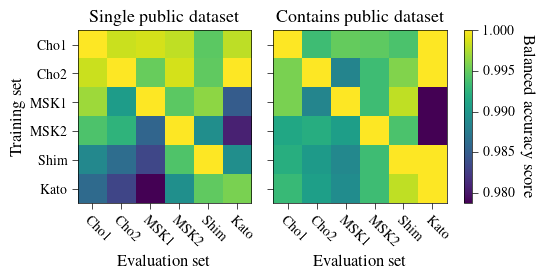

In [26]:
scaler_type = 'standard'

data_dir = os.path.join(
    cwd, 'results', 'datasets', 'lr',
    scaler_type, 'vanilla', 'params_multilabel.pt'
)
data = torch.load(data_dir, weights_only=True)

n_datasets = len(datasets_ids)

# Only use dataset to train
matrix1 = []
for train_did in range(n_datasets):
    eval_list = []
    for test_did in range(n_datasets):
        cond_vector = torch.zeros(n_datasets)
        cond_vector[train_did] = 1
        mask = (data['labels'] == cond_vector).all(dim=1).bool()

        accs = data['bal_accs'][mask, test_did]
        aucs = data['auc_scores'][mask, test_did]
        
        eval_list.append(accs.median().item())
    matrix1.append(eval_list)

matrix1 = torch.tensor(matrix1)
matrix1 = matrix1 / matrix1.max(dim=0, keepdim=True).values

# Train on bigger dataset that contains a dataset
matrix2 = []
for train_did in range(n_datasets):
    eval_list = []
    for test_did in range(n_datasets):
        mask = data['labels'][:, train_did] == 1

        accs = data['bal_accs'][mask, test_did]
        aucs = data['auc_scores'][mask, test_did]
        
        eval_list.append(accs.median().item())
    matrix2.append(eval_list)

matrix2 = torch.tensor(matrix2)
matrix2 = matrix2 / matrix2.max(dim=0, keepdim=True).values

# Find global min and max across both matrices
vmin = min(matrix1.min().item(), matrix2.min().item())
vmax = max(matrix1.max().item(), matrix2.max().item())

# fig, ax = plt.subplots(1, 2, figsize=(8, 3.25))
fig, ax = plt.subplots(
    1, 2, figsize=(5.5, 2.25),
    gridspec_kw={'wspace': 0.01}  # small gap between heatmaps
)

x_labels = [datasets_dict[datasets[i]]
            for i in range(n_datasets)]
y_labels = [datasets_dict[datasets[i]]
            for i in range(n_datasets)]

# Plot the matrix1
im1 = ax[0].imshow(matrix1, cmap='viridis')

ax[0].set_xticks(range(n_datasets))
ax[0].set_yticks(range(n_datasets))
ax[0].set_xticklabels(x_labels, rotation=-45,
                      ha='left', rotation_mode='anchor')
ax[0].set_yticklabels(y_labels)
ax[0].set_xlabel('Evaluation set')
ax[0].set_ylabel('Training set')
ax[0].set_title('Single public dataset')

# Plot the matrix2
im2 = ax[1].imshow(matrix2, cmap='viridis')

ax[1].set_xticks(range(n_datasets))
ax[1].set_yticks(range(n_datasets))
ax[1].set_xticklabels(x_labels, rotation=-45,
                      ha='left', rotation_mode='anchor')
ax[1].set_yticklabels([''] * n_datasets)
ax[1].set_xlabel('Evaluation set')
ax[1].set_title('Contains public dataset')

# Add colorbar
cbar = fig.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Balanced accuracy score', rotation=270, labelpad=15)

# Show plot
# plt.savefig(os.path.join(figures_dir, 'accuracies_heatmap.pdf'),
#             bbox_inches='tight')
plt.show()

## Models trained on Chowell_train

In [28]:
scaler_type = 'standard'

for model_name in ['lr']:
    for model_type in ['vanilla', 'average']:
        print(f'{model_name.upper()} | {model_type.upper()}', end=' | ')
        data_dir = os.path.join(
            cwd, 'results', 'datasets', model_name,
            scaler_type, model_type, 'params_multilabel.pt'
        )
        data = torch.load(data_dir, weights_only=True)

        n_datasets = len(datasets_ids)
        for test_did in range(n_datasets):
            cond_vector = torch.zeros(n_datasets)
            cond_vector[0] = 1
            mask = (data['labels'] == cond_vector).all(dim=1).bool()
            
            accs = data['bal_accs'][mask, test_did]
            aucs = data['auc_scores'][mask, test_did]
            
            print(f'{accs.median().item():.2f}, {aucs.median().item():.2f}', end=' | ')
        print()

LR | VANILLA | 0.68, 0.74 | 0.69, 0.75 | 0.68, 0.70 | 0.63, 0.63 | 0.62, 0.60 | 0.78, 0.75 | 
LR | AVERAGE | 0.68, 0.74 | 0.69, 0.75 | 0.69, 0.70 | 0.63, 0.63 | 0.62, 0.60 | 0.78, 0.71 | 


In [199]:
scaler_type = 'standard'
model_type = 'vanilla'
model_name = 'lr_dp'

epsilon_list = [0.1, 1.0, 10.0, 100.0]
for epsilon in epsilon_list:
    print(f'{model_name.upper()} ({epsilon:<6.1f}) | {model_type.upper()}', end=' | ')
    data_dir = os.path.join(
        cwd, 'results', 'datasets', model_name,
        scaler_type, 'vanilla', f'params_multilabel_{epsilon}.pt'
    )
    data = torch.load(data_dir, weights_only=True)

    n_datasets = len(datasets_ids)
    for test_did in range(n_datasets):
        cond_vector = torch.zeros(n_datasets)
        cond_vector[0] = 1
        mask = (data['labels'] == cond_vector).all(dim=1).bool()
        
        accs = data['bal_accs'][mask, test_did]
        aucs = data['auc_scores'][mask, test_did]
        
        print(f'{accs.median().item():.2f}, {aucs.median().item():.2f}', end=' | ')
    print()

LR_DP (0.1   ) | VANILLA | 0.52, 0.49 | 0.53, 0.49 | 0.53, 0.50 | 0.56, 0.49 | 0.53, 0.49 | 0.58, 0.49 | 
LR_DP (1.0   ) | VANILLA | 0.56, 0.56 | 0.57, 0.57 | 0.56, 0.55 | 0.60, 0.55 | 0.56, 0.54 | 0.62, 0.51 | 
LR_DP (10.0  ) | VANILLA | 0.67, 0.72 | 0.68, 0.73 | 0.66, 0.68 | 0.63, 0.62 | 0.61, 0.59 | 0.70, 0.64 | 
LR_DP (100.0 ) | VANILLA | 0.68, 0.74 | 0.69, 0.75 | 0.68, 0.70 | 0.63, 0.63 | 0.62, 0.60 | 0.78, 0.75 | 


In [33]:
scaler_type = 'standard'
model_type = 'vanilla'
model_name = 'tt_lr'

n_bins_list = [2, 6, 10]
for n_bins in n_bins_list:
    print(f'{model_name.upper()} ({n_bins:<2}) | {model_type.upper()}', end=' | ')
    data_dir = os.path.join(
        cwd, 'results', 'datasets', model_name,
        scaler_type, model_type, f'params_multilabel_{n_bins}.pt'
    )
    data = torch.load(data_dir, weights_only=True)

    n_datasets = len(datasets_ids)
    for test_did in range(n_datasets):
        cond_vector = torch.zeros(n_datasets)
        cond_vector[0] = 1
        mask = (data['labels'] == cond_vector).all(dim=1).bool()
        
        accs = data['bal_accs'][mask, test_did]
        aucs = data['auc_scores'][mask, test_did]
        
        print(f'{accs.median().item():.2f}, {aucs.median().item():.2f}', end=' | ')
    print()

TT_LR (2 ) | VANILLA | 0.66, 0.69 | 0.66, 0.69 | 0.65, 0.67 | 0.63, 0.62 | 0.61, 0.60 | 0.70, 0.62 | 
TT_LR (6 ) | VANILLA | 0.67, 0.72 | 0.67, 0.72 | 0.67, 0.69 | 0.63, 0.63 | 0.62, 0.60 | 0.72, 0.65 | 
TT_LR (10) | VANILLA | 0.67, 0.72 | 0.68, 0.72 | 0.67, 0.69 | 0.63, 0.63 | 0.62, 0.60 | 0.73, 0.65 | 


In [35]:
model_name = 'nn'

print(f'{model_name.upper()}', end=' | ')
data_dir = os.path.join(
    cwd, 'results', 'datasets', model_name, 'params_multilabel.pt')
data = torch.load(data_dir, weights_only=True)

n_datasets = len(datasets_ids)
for test_did in range(n_datasets):
    cond_vector = torch.zeros(n_datasets)
    cond_vector[0] = 1
    mask = (data['labels'] == cond_vector).all(dim=1).bool()
    
    accs = data['bal_accs'][mask, test_did]
    aucs = data['auc_scores'][mask, test_did]
    
    print(f'{accs.median().item():.2f}, {aucs.median().item():.2f}', end=' | ')
print()

NN | 0.72, 0.78 | 0.69, 0.74 | 0.64, 0.66 | 0.63, 0.61 | 0.62, 0.63 | 0.80, 0.75 | 


In [37]:
scaler_type = 'standard'
model_type = 'vanilla'
model_name = 'tt_nn'

n_bins_list = [2, 6, 10]
for n_bins in n_bins_list:
    print(f'{model_name.upper()} ({n_bins:<2}) | {model_type.upper()}', end=' | ')
    data_dir = os.path.join(
        cwd, 'results', 'datasets', model_name, f'params_multilabel_{n_bins}.pt')
    data = torch.load(data_dir, weights_only=True)

    n_datasets = len(datasets_ids)
    for test_did in range(n_datasets):
        cond_vector = torch.zeros(n_datasets)
        cond_vector[0] = 1
        mask = (data['labels'] == cond_vector).all(dim=1).bool()
        
        accs = data['bal_accs'][mask, test_did]
        aucs = data['auc_scores'][mask, test_did]
        
        print(f'{accs.median().item():.2f}, {aucs.median().item():.2f}', end=' | ')
    print()

TT_NN (2 ) | VANILLA | 0.66, 0.70 | 0.67, 0.69 | 0.63, 0.65 | 0.65, 0.62 | 0.61, 0.60 | 0.72, 0.67 | 
TT_NN (6 ) | VANILLA | 0.68, 0.73 | 0.69, 0.74 | 0.65, 0.67 | 0.64, 0.62 | 0.62, 0.62 | 0.77, 0.73 | 
TT_NN (10) | VANILLA | 0.68, 0.73 | 0.69, 0.73 | 0.65, 0.67 | 0.64, 0.62 | 0.62, 0.62 | 0.75, 0.71 | 


## Accuracies Chowell_train vs Chowell_train + Kato

In [38]:
plt.rc('font', family='serif', serif='Computer Modern', size=16)
plt.rc('text', usetex=True)

# Font sizes
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 15   # Title font size
plt.rcParams['axes.labelsize'] = 12   # Axis label font size
plt.rcParams['xtick.labelsize'] = 10  # X-axis tick label font size
plt.rcParams['ytick.labelsize'] = 10  # Y-axis tick label font size
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['legend.title_fontsize'] = 10

# Lines
plt.rcParams['axes.linewidth'] = 0.5  # Default is usually 1.0

# Ticks
plt.rcParams['xtick.major.width'] = 0.5   # Width of major ticks on X-axis
plt.rcParams['ytick.major.width'] = 0.5   # Width of major ticks on Y-axis
plt.rcParams['xtick.minor.width'] = 0.4   # Width of minor ticks on X-axis
plt.rcParams['ytick.minor.width'] = 0.4   # Width of minor ticks on Y-axis

plt.rcParams['xtick.major.size'] = 4
plt.rcParams['ytick.major.size'] = 4
plt.rcParams['xtick.minor.size'] = 2
plt.rcParams['ytick.minor.size'] = 2


figures_dir = os.path.join(cwd, 'figures')
os.makedirs(figures_dir, exist_ok=True)

In [44]:
# Accs
scaler_type = 'standard'
n_datasets = len(datasets_ids)

for model_type in ['vanilla', 'average']:
    # LR
    data_dir = os.path.join(
        cwd, 'results', 'datasets', 'lr',
        scaler_type, model_type, 'params_multilabel.pt'
    )
    data = torch.load(data_dir, weights_only=True)

    matrix1 = []
    for train_did in [[0], [0, 5]]:
        eval_list = []
        for test_did in [0, 5]:
            cond_vector = torch.zeros(n_datasets)
            cond_vector[train_did] = 1
            mask = (data['labels'] == cond_vector).all(dim=1).bool()

            accs = data['bal_accs'][mask, test_did]
            aucs = data['auc_scores'][mask, test_did]
            
            eval_list.append(accs.median().item())
        matrix1.append(eval_list)

    matrix1 = torch.tensor(matrix1)

    # TT
    if model_type == 'average':
        matrix2 = torch.zeros(2, 2)
    
    else:
        data_dir = os.path.join(
            cwd, 'results', 'datasets', 'tt_lr',
            scaler_type, model_type, 'params_multilabel_6.pt'
        )
        data = torch.load(data_dir, weights_only=True)

        matrix2 = []
        for train_did in [[0], [0, 5]]:
            eval_list = []
            for test_did in [0, 5]:
                cond_vector = torch.zeros(n_datasets)
                cond_vector[train_did] = 1
                mask = (data['labels'] == cond_vector).all(dim=1).bool()

                accs = data['bal_accs'][mask, test_did]
                aucs = data['auc_scores'][mask, test_did]
                
                eval_list.append(accs.median().item())
            matrix2.append(eval_list)

        matrix2 = torch.tensor(matrix2)
    
    print(model_type)
    print(matrix1)
    print(matrix2)
    print()

vanilla
tensor([[0.6803, 0.7833],
        [0.6822, 0.8000]])
tensor([[0.6650, 0.7167],
        [0.6687, 0.7500]])

average
tensor([[0.6805, 0.7833],
        [0.6803, 0.8167]])
tensor([[0., 0.],
        [0., 0.]])



In [45]:
# AUCs
scaler_type = 'standard'
n_datasets = len(datasets_ids)


for model_type in ['vanilla', 'average']:
    # LR
    data_dir = os.path.join(
        cwd, 'results', 'datasets', 'lr',
        scaler_type, model_type, 'params_multilabel.pt'
    )
    data = torch.load(data_dir, weights_only=True)

    matrix1 = []
    for train_did in [[0], [0, 5]]:
        eval_list = []
        for test_did in [0, 5]:
            cond_vector = torch.zeros(n_datasets)
            cond_vector[train_did] = 1
            mask = (data['labels'] == cond_vector).all(dim=1).bool()

            accs = data['bal_accs'][mask, test_did]
            aucs = data['auc_scores'][mask, test_did]
            
            eval_list.append(aucs.median().item())
        matrix1.append(eval_list)

    matrix1 = torch.tensor(matrix1)

    # TT
    if model_type == 'average':
        matrix2 = torch.zeros(2, 2)
    
    else:
        data_dir = os.path.join(
            cwd, 'results', 'datasets', 'tt_lr',
            scaler_type, model_type, 'params_multilabel_6.pt'
        )
        data = torch.load(data_dir, weights_only=True)

        matrix2 = []
        for train_did in [[0], [0, 5]]:
            eval_list = []
            for test_did in [0, 5]:
                cond_vector = torch.zeros(n_datasets)
                cond_vector[train_did] = 1
                mask = (data['labels'] == cond_vector).all(dim=1).bool()

                accs = data['bal_accs'][mask, test_did]
                aucs = data['auc_scores'][mask, test_did]
                
                eval_list.append(aucs.median().item())
            matrix2.append(eval_list)

        matrix2 = torch.tensor(matrix2)

    print(model_type)
    print(matrix1)
    print(matrix2)
    print()

vanilla
tensor([[0.7411, 0.7533],
        [0.7415, 0.7733]])
tensor([[0.7171, 0.6533],
        [0.7204, 0.6900]])

average
tensor([[0.7437, 0.7133],
        [0.7446, 0.7800]])
tensor([[0., 0.],
        [0., 0.]])



# Attacks

## Models trained on each dataset

### Weak Black-Box

In [46]:
attack_name = 'weak'
scaler_type = 'standard'

for model_type in ['vanilla', 'average']:
    print(f'{model_type}:')
    for model_name in ['lr']:
        attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                    scaler_type, model_type)
        
        data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                                scaler_type, model_type, 'params_multilabel.pt')
        data = torch.load(data_dir, weights_only=True)
        
        X, y = data['bin_scores'], data['labels']
        
        mask = torch.zeros(X.size(0), dtype=torch.bool)
        for i in range(n_datasets):
            cond_vector = torch.zeros(n_datasets)
            cond_vector[i] = 1
            mask = torch.logical_or(mask,
                                    (data['labels'] == cond_vector).all(dim=1))
        
        n_splits = 5
        n_repeats = 5
        repkfold = RepeatedKFold(n_splits=n_splits,
                                 n_repeats=n_repeats,
                                 random_state=1)
        
        values = []
        for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
            mlp_bb = joblib.load(
                os.path.join(attacker_dir,
                             f'mlp_bb_{attack_name}_{i+1}.pkl'))
            
            aux_mask = mask[test_idx]
            X_test, y_test = X[test_idx][aux_mask], y[test_idx][aux_mask]
            
            y_pred = mlp_bb.predict(X_test)
            val = 1 - hamming_loss(y_test, y_pred)
            values.append(val)
        
        values = torch.tensor(values)
        print(f'Ham. Acc. {model_name}: mean = {values.mean():.4f}, std = {values.std():.4f}')
    print()

vanilla:
Ham. Acc. lr: mean = 0.9139, std = 0.0105

average:
Ham. Acc. lr: mean = 0.9527, std = 0.0187



In [200]:
attack_name = 'weak'
scaler_type = 'standard'
model_type = 'vanilla'
model_name = 'lr_dp'

epsilon_list = [0.1, 1.0, 10.0, 100.0]
epsilon_dict = {
    0.1   : '0.1',
    1.0   : '1',
    10.0  : '10',
    100.0 : '100'}

print(f'{model_type}:')
for epsilon in epsilon_list:
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                scaler_type, model_type)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            scaler_type, model_type,
                            f'params_multilabel_{epsilon}.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['bin_scores'], data['labels']
    
    mask = torch.zeros(X.size(0), dtype=torch.bool)
    for i in range(n_datasets):
        cond_vector = torch.zeros(n_datasets)
        cond_vector[i] = 1
        mask = torch.logical_or(mask,
                                (data['labels'] == cond_vector).all(dim=1))
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                                n_repeats=n_repeats,
                                random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        mlp_bb = joblib.load(
            os.path.join(attacker_dir,
                            f'mlp_bb_{attack_name}_{epsilon}_{i+1}.pkl'))
        
        aux_mask = mask[test_idx]
        X_test, y_test = X[test_idx][aux_mask], y[test_idx][aux_mask]
        
        y_pred = mlp_bb.predict(X_test)
        val = 1 - hamming_loss(y_test, y_pred)
        values.append(val)
    
    values = torch.tensor(values)
    print(fr'Ham. Acc. {model_name} ($\varepsilon=${epsilon_dict[epsilon]}): '
          fr'mean = {values.mean():.4f}, std = {values.std():.4f}')
print()

vanilla:
Ham. Acc. lr_dp ($\varepsilon=$0.1): mean = 0.5890, std = 0.0345
Ham. Acc. lr_dp ($\varepsilon=$1): mean = 0.5941, std = 0.0283
Ham. Acc. lr_dp ($\varepsilon=$10): mean = 0.7526, std = 0.0233
Ham. Acc. lr_dp ($\varepsilon=$100): mean = 0.8371, std = 0.0242



In [48]:
attack_name = 'weak'
scaler_type = 'standard'
model_type = 'vanilla'
model_name = 'tt_lr'

n_bins_list = [2, 6, 10]

print(f'{model_type}:')
for n_bins in n_bins_list:
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                scaler_type, model_type)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            scaler_type, model_type,
                            f'params_multilabel_{n_bins}.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['bin_scores'], data['labels']
    
    mask = torch.zeros(X.size(0), dtype=torch.bool)
    for i in range(n_datasets):
        cond_vector = torch.zeros(n_datasets)
        cond_vector[i] = 1
        mask = torch.logical_or(mask,
                                (data['labels'] == cond_vector).all(dim=1))
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                                n_repeats=n_repeats,
                                random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        mlp_bb = joblib.load(
            os.path.join(attacker_dir,
                            f'mlp_bb_{attack_name}_{n_bins}_{i+1}.pkl'))
        
        aux_mask = mask[test_idx]
        X_test, y_test = X[test_idx][aux_mask], y[test_idx][aux_mask]
        
        y_pred = mlp_bb.predict(X_test)
        val = 1 - hamming_loss(y_test, y_pred)
        values.append(val)
    
    values = torch.tensor(values)
    print(fr'Ham. Acc. {model_name} ($\b=${n_bins}): '
          fr'mean = {values.mean():.4f}, std = {values.std():.4f}')
print()

vanilla:
Ham. Acc. tt_lr ($\b=$2): mean = 0.7164, std = 0.0188
Ham. Acc. tt_lr ($\b=$6): mean = 0.8517, std = 0.0087
Ham. Acc. tt_lr ($\b=$10): mean = 0.8662, std = 0.0090



In [49]:
attack_name = 'weak'
model_name = 'nn'

attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name)

data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                        'params_multilabel.pt')
data = torch.load(data_dir, weights_only=True)

X, y = data['bin_scores'], data['labels']

mask = torch.zeros(X.size(0), dtype=torch.bool)
for i in range(n_datasets):
    cond_vector = torch.zeros(n_datasets)
    cond_vector[i] = 1
    mask = torch.logical_or(mask,
                            (data['labels'] == cond_vector).all(dim=1))

n_splits = 5
n_repeats = 5
repkfold = RepeatedKFold(n_splits=n_splits,
                            n_repeats=n_repeats,
                            random_state=1)

values = []
for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
    mlp_bb = joblib.load(
        os.path.join(attacker_dir,
                     f'mlp_bb_{attack_name}_{i+1}.pkl'))
    
    aux_mask = mask[test_idx]
    X_test, y_test = X[test_idx][aux_mask], y[test_idx][aux_mask]
    
    y_pred = mlp_bb.predict(X_test)
    val = 1 - hamming_loss(y_test, y_pred)
    values.append(val)

values = torch.tensor(values)
print(f'Ham. Acc. {model_name}: mean = {values.mean():.4f}, std = {values.std():.4f}')
print()

Ham. Acc. nn: mean = 0.7970, std = 0.0261



In [50]:
attack_name = 'weak'
model_name = 'tt_nn'

n_bins_list = [2, 6, 10]

for n_bins in n_bins_list:
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            f'params_multilabel_{n_bins}.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['bin_scores'], data['labels']
    
    mask = torch.zeros(X.size(0), dtype=torch.bool)
    for i in range(n_datasets):
        cond_vector = torch.zeros(n_datasets)
        cond_vector[i] = 1
        mask = torch.logical_or(mask,
                                (data['labels'] == cond_vector).all(dim=1))
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                                n_repeats=n_repeats,
                                random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        mlp_bb = joblib.load(
            os.path.join(attacker_dir,
                         f'mlp_bb_{attack_name}_{n_bins}_{i+1}.pkl'))
        
        aux_mask = mask[test_idx]
        X_test, y_test = X[test_idx][aux_mask], y[test_idx][aux_mask]
        
        y_pred = mlp_bb.predict(X_test)
        val = 1 - hamming_loss(y_test, y_pred)
        values.append(val)
    
    values = torch.tensor(values)
    print(fr'Ham. Acc. {model_name} ($\b=${n_bins}): '
          fr'mean = {values.mean():.4f}, std = {values.std():.4f}')
print()

Ham. Acc. tt_nn ($\b=$2): mean = 0.5751, std = 0.0403
Ham. Acc. tt_nn ($\b=$6): mean = 0.6213, std = 0.0326
Ham. Acc. tt_nn ($\b=$10): mean = 0.7318, std = 0.0384



### Strong Black-Box

In [66]:
attack_name = 'strong'
scaler_type = 'standard'

for model_type in ['vanilla', 'average']:
    print(f'{model_type}:')
    for model_name in ['lr']:
        attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                    scaler_type, model_type)
        
        data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                                scaler_type, model_type, 'params_multilabel.pt')
        data = torch.load(data_dir, weights_only=True)
        
        X, y = data['out_scores'], data['labels']
        
        mask = torch.zeros(X.size(0), dtype=torch.bool)
        for i in range(n_datasets):
            cond_vector = torch.zeros(n_datasets)
            cond_vector[i] = 1
            mask = torch.logical_or(mask,
                                    (data['labels'] == cond_vector).all(dim=1))
        
        n_splits = 5
        n_repeats = 5
        repkfold = RepeatedKFold(n_splits=n_splits,
                                 n_repeats=n_repeats,
                                 random_state=1)
        
        values = []
        for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
            mlp_bb = joblib.load(
                os.path.join(attacker_dir,
                             f'mlp_bb_{attack_name}_{i+1}.pkl'))
            
            aux_mask = mask[test_idx]
            X_test, y_test = X[test_idx][aux_mask], y[test_idx][aux_mask]
            
            y_pred = mlp_bb.predict(X_test)
            val = 1 - hamming_loss(y_test, y_pred)
            values.append(val)
        
        values = torch.tensor(values)
        print(f'Ham. Acc. {model_name}: mean = {values.mean():.4f}, std = {values.std():.4f}')
    print()

vanilla:
Ham. Acc. lr: mean = 0.9411, std = 0.0152

average:
Ham. Acc. lr: mean = 0.9819, std = 0.0212



In [201]:
attack_name = 'strong'
scaler_type = 'standard'
model_type = 'vanilla'
model_name = 'lr_dp'

epsilon_list = [0.1, 1.0, 10.0, 100.0]
epsilon_dict = {
    0.1   : '0.1',
    1.0   : '1',
    10.0  : '10',
    100.0 : '100'}

print(f'{model_type}:')
for epsilon in epsilon_list:
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                scaler_type, model_type)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            scaler_type, model_type,
                            f'params_multilabel_{epsilon}.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['out_scores'], data['labels']
    
    mask = torch.zeros(X.size(0), dtype=torch.bool)
    for i in range(n_datasets):
        cond_vector = torch.zeros(n_datasets)
        cond_vector[i] = 1
        mask = torch.logical_or(mask,
                                (data['labels'] == cond_vector).all(dim=1))
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                                n_repeats=n_repeats,
                                random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        mlp_bb = joblib.load(
            os.path.join(attacker_dir,
                            f'mlp_bb_{attack_name}_{epsilon}_{i+1}.pkl'))
        
        aux_mask = mask[test_idx]
        X_test, y_test = X[test_idx][aux_mask], y[test_idx][aux_mask]
        
        y_pred = mlp_bb.predict(X_test)
        val = 1 - hamming_loss(y_test, y_pred)
        values.append(val)
    
    values = torch.tensor(values)
    print(fr'Ham. Acc. {model_name} ($\varepsilon=${epsilon_dict[epsilon]}): '
          fr'mean = {values.mean():.4f}, std = {values.std():.4f}')
print()

vanilla:
Ham. Acc. lr_dp ($\varepsilon=$0.1): mean = 0.5956, std = 0.0208
Ham. Acc. lr_dp ($\varepsilon=$1): mean = 0.6031, std = 0.0237
Ham. Acc. lr_dp ($\varepsilon=$10): mean = 0.7856, std = 0.0274
Ham. Acc. lr_dp ($\varepsilon=$100): mean = 0.8638, std = 0.0447



In [68]:
attack_name = 'strong'
scaler_type = 'standard'
model_type = 'vanilla'
model_name = 'tt_lr'

n_bins_list = [2, 6, 10]

print(f'{model_type}:')
for n_bins in n_bins_list:
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                scaler_type, model_type)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            scaler_type, model_type,
                            f'params_multilabel_{n_bins}.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['out_scores'], data['labels']
    
    mask = torch.zeros(X.size(0), dtype=torch.bool)
    for i in range(n_datasets):
        cond_vector = torch.zeros(n_datasets)
        cond_vector[i] = 1
        mask = torch.logical_or(mask,
                                (data['labels'] == cond_vector).all(dim=1))
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                                n_repeats=n_repeats,
                                random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        mlp_bb = joblib.load(
            os.path.join(attacker_dir,
                            f'mlp_bb_{attack_name}_{n_bins}_{i+1}.pkl'))
        
        aux_mask = mask[test_idx]
        X_test, y_test = X[test_idx][aux_mask], y[test_idx][aux_mask]
        
        y_pred = mlp_bb.predict(X_test)
        val = 1 - hamming_loss(y_test, y_pred)
        values.append(val)
    
    values = torch.tensor(values)
    print(fr'Ham. Acc. {model_name} ($\b=${n_bins}): '
          fr'mean = {values.mean():.4f}, std = {values.std():.4f}')
print()

vanilla:
Ham. Acc. tt_lr ($\b=$2): mean = 0.8963, std = 0.0151
Ham. Acc. tt_lr ($\b=$6): mean = 0.9099, std = 0.0168
Ham. Acc. tt_lr ($\b=$10): mean = 0.9186, std = 0.0115



In [69]:
attack_name = 'strong'
model_name = 'nn'

attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name)

data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                        'params_multilabel.pt')
data = torch.load(data_dir, weights_only=True)

X, y = data['out_scores'], data['labels']

mask = torch.zeros(X.size(0), dtype=torch.bool)
for i in range(n_datasets):
    cond_vector = torch.zeros(n_datasets)
    cond_vector[i] = 1
    mask = torch.logical_or(mask,
                            (data['labels'] == cond_vector).all(dim=1))

n_splits = 5
n_repeats = 5
repkfold = RepeatedKFold(n_splits=n_splits,
                            n_repeats=n_repeats,
                            random_state=1)

values = []
for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
    mlp_bb = joblib.load(
        os.path.join(attacker_dir,
                     f'mlp_bb_{attack_name}_{i+1}.pkl'))
    
    aux_mask = mask[test_idx]
    X_test, y_test = X[test_idx][aux_mask], y[test_idx][aux_mask]
    
    y_pred = mlp_bb.predict(X_test)
    val = 1 - hamming_loss(y_test, y_pred)
    values.append(val)

values = torch.tensor(values)
print(f'Ham. Acc. {model_name}: mean = {values.mean():.4f}, std = {values.std():.4f}')
print()

Ham. Acc. nn: mean = 0.8770, std = 0.0458



In [70]:
attack_name = 'strong'
model_name = 'tt_nn'

n_bins_list = [2, 6, 10]

for n_bins in n_bins_list:
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            f'params_multilabel_{n_bins}.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['out_scores'], data['labels']
    
    mask = torch.zeros(X.size(0), dtype=torch.bool)
    for i in range(n_datasets):
        cond_vector = torch.zeros(n_datasets)
        cond_vector[i] = 1
        mask = torch.logical_or(mask,
                                (data['labels'] == cond_vector).all(dim=1))
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                                n_repeats=n_repeats,
                                random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        mlp_bb = joblib.load(
            os.path.join(attacker_dir,
                         f'mlp_bb_{attack_name}_{n_bins}_{i+1}.pkl'))
        
        aux_mask = mask[test_idx]
        X_test, y_test = X[test_idx][aux_mask], y[test_idx][aux_mask]
        
        y_pred = mlp_bb.predict(X_test)
        val = 1 - hamming_loss(y_test, y_pred)
        values.append(val)
    
    values = torch.tensor(values)
    print(fr'Ham. Acc. {model_name} ($\b=${n_bins}): '
          fr'mean = {values.mean():.4f}, std = {values.std():.4f}')
print()

Ham. Acc. tt_nn ($\b=$2): mean = 0.5973, std = 0.0317
Ham. Acc. tt_nn ($\b=$6): mean = 0.8510, std = 0.0208
Ham. Acc. tt_nn ($\b=$10): mean = 0.8685, std = 0.0575



### White-Box

In [72]:
scaler_type = 'standard'

for model_type in ['vanilla', 'average']:
    print(f'{model_type}:')
    for model_name in ['lr']:
        attacker_dir = os.path.join(cwd, 'results', 'attacks', 'wb', model_name,
                                    scaler_type, model_type)
        
        data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                                scaler_type, model_type, 'params_multilabel.pt')
        data = torch.load(data_dir, weights_only=True)
    
        X, y = data['params'], data['labels']
        
        mask = torch.zeros(X.size(0), dtype=torch.bool)
        for i in range(n_datasets):
            cond_vector = torch.zeros(n_datasets)
            cond_vector[i] = 1
            mask = torch.logical_or(mask,
                                    (data['labels'] == cond_vector).all(dim=1))
        
        n_splits = 5
        n_repeats = 5
        repkfold = RepeatedKFold(n_splits=n_splits,
                                 n_repeats=n_repeats,
                                 random_state=1)
        
        values = []
        for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
            # Load models
            n_splits = 5
            loaded_models = []
            
            # Load each model
            for j in range(n_splits):
                mlp_wb = joblib.load(os.path.join(attacker_dir,
                                                  f'mlp_wb_fold_{j+1}_{i+1}.pkl'))
                loaded_models.append(mlp_wb)
            
            aux_mask = mask[test_idx]
            X_test, y_test = X[test_idx][aux_mask], y[test_idx][aux_mask]
            
            all_preds = np.array([model.predict_proba(X_test)
                                  for model in loaded_models])
            avg_preds = np.mean(all_preds, axis=0)
            y_pred = (avg_preds >= 0.5).astype(int)
            
            val = 1 - hamming_loss(y_test, y_pred)
            values.append(val)
        
        values = torch.tensor(values)
        print(f'Ham. Acc. {model_name}: mean = {values.mean():.4f}, std = {values.std():.4f}')
    print()

vanilla:
Ham. Acc. lr: mean = 0.9592, std = 0.0036

average:
Ham. Acc. lr: mean = 0.9999, std = 0.0002



In [202]:
scaler_type = 'standard'
model_type = 'vanilla'
model_name = 'lr_dp'

epsilon_list = [0.1, 1.0, 10.0, 100.0]
epsilon_dict = {
    0.1   : '0.1',
    1.0   : '1',
    10.0  : '10',
    100.0 : '100.0'}

print(f'{model_type}:')
for epsilon in epsilon_list:
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'wb', model_name,
                                scaler_type, model_type)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            scaler_type, model_type,
                            f'params_multilabel_{epsilon}.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['params'], data['labels']
    
    mask = torch.zeros(X.size(0), dtype=torch.bool)
    for i in range(n_datasets):
        cond_vector = torch.zeros(n_datasets)
        cond_vector[i] = 1
        mask = torch.logical_or(mask,
                                (data['labels'] == cond_vector).all(dim=1))
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                             n_repeats=n_repeats,
                             random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        # Load models
        n_splits = 5
        loaded_models = []
        
        # Load each model
        for j in range(n_splits):
            mlp_wb = joblib.load(os.path.join(attacker_dir,
                                                f'mlp_wb_fold_{j+1}_{epsilon}_{i+1}.pkl'))
            loaded_models.append(mlp_wb)
        
        aux_mask = mask[test_idx]
        X_test, y_test = X[test_idx][aux_mask], y[test_idx][aux_mask]
        
        all_preds = np.array([model.predict_proba(X_test)
                                for model in loaded_models])
        avg_preds = np.mean(all_preds, axis=0)
        y_pred = (avg_preds >= 0.5).astype(int)
        
        val = 1 - hamming_loss(y_test, y_pred)
        values.append(val)
    
    values = torch.tensor(values)
    print(fr'Ham. Acc. {model_name} ($\varepsilon=${epsilon_dict[epsilon]}): '
          fr'mean = {values.mean():.4f}, std = {values.std():.4f}')
print()

vanilla:
Ham. Acc. lr_dp ($\varepsilon=$0.1): mean = 0.2284, std = 0.0460
Ham. Acc. lr_dp ($\varepsilon=$1): mean = 0.2664, std = 0.0616
Ham. Acc. lr_dp ($\varepsilon=$10): mean = 0.6207, std = 0.0429
Ham. Acc. lr_dp ($\varepsilon=$100.0): mean = 0.8451, std = 0.0150



In [ ]:
scaler_type = 'standard'
model_type = 'vanilla'
model_name = 'tt_lr'

n_bins_list = [2, 6, 10]

print(f'{model_type}:')
for n_bins in n_bins_list:
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'wb', model_name,
                                scaler_type, model_type)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            scaler_type, model_type,
                            f'params_multilabel_{n_bins}.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['cores'], data['labels']
    
    mask = torch.zeros(X.size(0), dtype=torch.bool)
    for i in range(n_datasets):
        cond_vector = torch.zeros(n_datasets)
        cond_vector[i] = 1
        mask = torch.logical_or(mask,
                                (data['labels'] == cond_vector).all(dim=1))
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                             n_repeats=n_repeats,
                             random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        # Load models
        n_splits = 5
        loaded_models = []
        
        # Load each model
        for j in range(n_splits):
            mlp_wb = joblib.load(os.path.join(attacker_dir,
                                                f'mlp_wb_fold_{j+1}_{n_bins}_{i+1}.pkl'))
            loaded_models.append(mlp_wb)
        
        aux_mask = mask[test_idx]
        X_test, y_test = X[test_idx][aux_mask], y[test_idx][aux_mask]
        
        all_preds = np.array([model.predict_proba(X_test)
                                for model in loaded_models])
        avg_preds = np.mean(all_preds, axis=0)
        y_pred = (avg_preds >= 0.5).astype(int)
        
        val = 1 - hamming_loss(y_test, y_pred)
        values.append(val)
    
    values = torch.tensor(values)
    print(fr'Ham. Acc. {model_name} ($\b=${n_bins}): '
          fr'mean = {values.mean():.4f}, std = {values.std():.4f}')
print()

In [ ]:
scaler_type = 'standard'
model_type = 'vanilla'
model_name = 'lr_tt'

n_bins_list = [2, 6, 10]

print(f'{model_type}:')
for n_bins in n_bins_list:
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'wb', model_name,
                                scaler_type, model_type)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            scaler_type, model_type,
                            f'params_multilabel_{n_bins}.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['cores'], data['labels']
    
    mask = torch.zeros(X.size(0), dtype=torch.bool)
    for i in range(n_datasets):
        cond_vector = torch.zeros(n_datasets)
        cond_vector[i] = 1
        mask = torch.logical_or(mask,
                                (data['labels'] == cond_vector).all(dim=1))
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                             n_repeats=n_repeats,
                             random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        # Load models
        n_splits = 5
        loaded_models = []
        
        # Load each model
        for j in range(n_splits):
            mlp_wb = joblib.load(os.path.join(attacker_dir,
                                                f'mlp_wb_fold_{j+1}_{n_bins}_{i+1}.pkl'))
            loaded_models.append(mlp_wb)
        
        aux_mask = mask[test_idx]
        X_test, y_test = X[test_idx][aux_mask], y[test_idx][aux_mask]
        
        all_preds = np.array([model.predict_proba(X_test)
                                for model in loaded_models])
        avg_preds = np.mean(all_preds, axis=0)
        y_pred = (avg_preds >= 0.5).astype(int)
        
        val = 1 - hamming_loss(y_test, y_pred)
        values.append(val)
    
    values = torch.tensor(values)
    print(fr'Ham. Acc. {model_name} ($\b=${n_bins}): '
          fr'mean = {values.mean():.4f}, std = {values.std():.4f}')
print()

In [74]:
scaler_type = 'standard'
model_name = 'nn'

attacker_dir = os.path.join(cwd, 'results', 'attacks', 'wb', model_name)

data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                        'params_multilabel.pt')
data = torch.load(data_dir, weights_only=True)

X, y = data['params'], data['labels']

mask = torch.zeros(X.size(0), dtype=torch.bool)
for i in range(n_datasets):
    cond_vector = torch.zeros(n_datasets)
    cond_vector[i] = 1
    mask = torch.logical_or(mask,
                            (data['labels'] == cond_vector).all(dim=1))

n_splits = 5
n_repeats = 5
repkfold = RepeatedKFold(n_splits=n_splits,
                            n_repeats=n_repeats,
                            random_state=1)

values = []
for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
    # Load models
    n_splits = 5
    loaded_models = []
    
    # Load each model
    for j in range(n_splits):
        mlp_wb = joblib.load(os.path.join(attacker_dir,
                                          f'mlp_wb_fold_{j+1}_{i+1}.pkl'))
        loaded_models.append(mlp_wb)
    
    aux_mask = mask[test_idx]
    X_test, y_test = X[test_idx][aux_mask], y[test_idx][aux_mask]
    
    all_preds = np.array([model.predict_proba(X_test)
                            for model in loaded_models])
    avg_preds = np.mean(all_preds, axis=0)
    y_pred = (avg_preds >= 0.5).astype(int)
    
    val = 1 - hamming_loss(y_test, y_pred)
    values.append(val)

values = torch.tensor(values)
print(f'Ham. Acc. {model_name}: mean = {values.mean():.4f}, std = {values.std():.4f}')
print()

Ham. Acc. nn: mean = 0.6867, std = 0.0187



In [76]:
model_name = 'tt_nn'

n_bins_list = [2, 6, 10]

for n_bins in n_bins_list:
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'wb', model_name)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            f'params_multilabel_{n_bins}.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['cores'], data['labels']
    
    mask = torch.zeros(X.size(0), dtype=torch.bool)
    for i in range(n_datasets):
        cond_vector = torch.zeros(n_datasets)
        cond_vector[i] = 1
        mask = torch.logical_or(mask,
                                (data['labels'] == cond_vector).all(dim=1))
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                             n_repeats=n_repeats,
                             random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        # Load models
        n_splits = 5
        loaded_models = []
        
        # Load each model
        for j in range(n_splits):
            mlp_wb = joblib.load(os.path.join(attacker_dir,
                                              f'mlp_wb_fold_{j+1}_{n_bins}_{i+1}.pkl'))
            loaded_models.append(mlp_wb)
        
        aux_mask = mask[test_idx]
        X_test, y_test = X[test_idx][aux_mask], y[test_idx][aux_mask]
        
        all_preds = np.array([model.predict_proba(X_test)
                                for model in loaded_models])
        avg_preds = np.mean(all_preds, axis=0)
        y_pred = (avg_preds >= 0.5).astype(int)
        
        val = 1 - hamming_loss(y_test, y_pred)
        values.append(val)
    
    values = torch.tensor(values)
    print(fr'Ham. Acc. {model_name} ($\b=${n_bins}): '
          fr'mean = {values.mean():.4f}, std = {values.std():.4f}')
print()

Ham. Acc. tt_nn ($\b=$2): mean = 0.5060, std = 0.0230
Ham. Acc. tt_nn ($\b=$6): mean = 0.4843, std = 0.0212
Ham. Acc. tt_nn ($\b=$10): mean = 0.5009, std = 0.0190



## Models trained on datasets that contains each dataset

### Weak Black-Box

In [77]:
attack_name = 'weak'
scaler_type = 'standard'

for model_type in ['vanilla', 'average']:
    print(f'{model_type}:')
    for model_name in ['lr']:
        attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                    scaler_type, model_type)
        
        data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                                scaler_type, model_type, 'params_multilabel.pt')
        data = torch.load(data_dir, weights_only=True)
        
        X, y = data['bin_scores'], data['labels']
        
        n_splits = 5
        n_repeats = 5
        repkfold = RepeatedKFold(n_splits=n_splits,
                                 n_repeats=n_repeats,
                                 random_state=1)
        
        values = []
        for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
            mlp_bb = joblib.load(
                os.path.join(attacker_dir,
                             f'mlp_bb_{attack_name}_{i+1}.pkl'))
            
            X_test, y_test = X[test_idx], y[test_idx]
            
            y_pred = mlp_bb.predict(X_test)
            val = 1 - hamming_loss(y_test, y_pred)
            values.append(val)
        
        values = torch.tensor(values)
        print(f'Ham. Acc. {model_name}: mean = {values.mean():.4f}, std = {values.std():.4f}')
    print()

vanilla:
Ham. Acc. lr: mean = 0.8178, std = 0.0035

average:
Ham. Acc. lr: mean = 0.9149, std = 0.0058



In [203]:
attack_name = 'weak'
scaler_type = 'standard'
model_type = 'vanilla'
model_name = 'lr_dp'

epsilon_list = [0.1, 1.0, 10.0, 100.0]
epsilon_dict = {
    0.1   : '0.1',
    1.0   : '1',
    10.0  : '10',
    100.0 : '100.0'}

print(f'{model_type}:')
for epsilon in epsilon_list:
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                scaler_type, model_type)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            scaler_type, model_type,
                            f'params_multilabel_{epsilon}.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['bin_scores'], data['labels']
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                                n_repeats=n_repeats,
                                random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        mlp_bb = joblib.load(
            os.path.join(attacker_dir,
                            f'mlp_bb_{attack_name}_{epsilon}_{i+1}.pkl'))
        
        X_test, y_test = X[test_idx], y[test_idx]
        
        y_pred = mlp_bb.predict(X_test)
        val = 1 - hamming_loss(y_test, y_pred)
        values.append(val)
    
    values = torch.tensor(values)
    print(fr'Ham. Acc. {model_name} ($\varepsilon=${epsilon_dict[epsilon]}): '
          fr'mean = {values.mean():.4f}, std = {values.std():.4f}')
print()

vanilla:
Ham. Acc. lr_dp ($\varepsilon=$0.1): mean = 0.5314, std = 0.0081
Ham. Acc. lr_dp ($\varepsilon=$1): mean = 0.5710, std = 0.0074
Ham. Acc. lr_dp ($\varepsilon=$10): mean = 0.7163, std = 0.0087
Ham. Acc. lr_dp ($\varepsilon=$100.0): mean = 0.7663, std = 0.0060



In [95]:
attack_name = 'weak'
scaler_type = 'standard'
model_type = 'vanilla'
model_name = 'tt_lr'

n_bins_list = [2, 6, 10]

print(f'{model_type}:')
for n_bins in n_bins_list:
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                scaler_type, model_type)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            scaler_type, model_type,
                            f'params_multilabel_{n_bins}.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['bin_scores'], data['labels']
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                                n_repeats=n_repeats,
                                random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        mlp_bb = joblib.load(
            os.path.join(attacker_dir,
                            f'mlp_bb_{attack_name}_{n_bins}_{i+1}.pkl'))
        
        X_test, y_test = X[test_idx], y[test_idx]
        
        y_pred = mlp_bb.predict(X_test)
        val = 1 - hamming_loss(y_test, y_pred)
        values.append(val)
    
    values = torch.tensor(values)
    print(fr'Ham. Acc. {model_name} ($\b=${n_bins}): '
          fr'mean = {values.mean():.4f}, std = {values.std():.4f}')
print()

vanilla:
Ham. Acc. tt_lr ($\b=$2): mean = 0.6666, std = 0.0025
Ham. Acc. tt_lr ($\b=$6): mean = 0.7535, std = 0.0022
Ham. Acc. tt_lr ($\b=$10): mean = 0.7687, std = 0.0020



In [96]:
attack_name = 'weak'
model_name = 'nn'

attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name)

data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                        'params_multilabel.pt')
data = torch.load(data_dir, weights_only=True)

X, y = data['bin_scores'], data['labels']

n_splits = 5
n_repeats = 5
repkfold = RepeatedKFold(n_splits=n_splits,
                            n_repeats=n_repeats,
                            random_state=1)

values = []
for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
    mlp_bb = joblib.load(
        os.path.join(attacker_dir,
                     f'mlp_bb_{attack_name}_{i+1}.pkl'))
    
    X_test, y_test = X[test_idx], y[test_idx]
    
    y_pred = mlp_bb.predict(X_test)
    val = 1 - hamming_loss(y_test, y_pred)
    values.append(val)

values = torch.tensor(values)
print(f'Ham. Acc. {model_name}: mean = {values.mean():.4f}, std = {values.std():.4f}')
print()

Ham. Acc. nn: mean = 0.7375, std = 0.0056



In [98]:
attack_name = 'weak'
model_name = 'tt_nn'

n_bins_list = [2, 6, 10]

for n_bins in n_bins_list:
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            f'params_multilabel_{n_bins}.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['bin_scores'], data['labels']
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                                n_repeats=n_repeats,
                                random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        mlp_bb = joblib.load(
            os.path.join(attacker_dir,
                         f'mlp_bb_{attack_name}_{n_bins}_{i+1}.pkl'))
        
        X_test, y_test = X[test_idx], y[test_idx]
        
        y_pred = mlp_bb.predict(X_test)
        val = 1 - hamming_loss(y_test, y_pred)
        values.append(val)
    
    values = torch.tensor(values)
    print(fr'Ham. Acc. {model_name} ($\b=${n_bins}): '
          fr'mean = {values.mean():.4f}, std = {values.std():.4f}')
print()

Ham. Acc. tt_nn ($\b=$2): mean = 0.5759, std = 0.0055
Ham. Acc. tt_nn ($\b=$6): mean = 0.6252, std = 0.0051
Ham. Acc. tt_nn ($\b=$10): mean = 0.6544, std = 0.0057



### Strong Black-Box

In [82]:
attack_name = 'strong'
scaler_type = 'standard'

for model_type in ['vanilla', 'average']:
    print(f'{model_type}:')
    for model_name in ['lr']:
        attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                    scaler_type, model_type)
        
        data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                                scaler_type, model_type, 'params_multilabel.pt')
        data = torch.load(data_dir, weights_only=True)
        
        X, y = data['out_scores'], data['labels']
        
        n_splits = 5
        n_repeats = 5
        repkfold = RepeatedKFold(n_splits=n_splits,
                                 n_repeats=n_repeats,
                                 random_state=1)
        
        values = []
        for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
            mlp_bb = joblib.load(
                os.path.join(attacker_dir,
                             f'mlp_bb_{attack_name}_{i+1}.pkl'))
            
            X_test, y_test = X[test_idx], y[test_idx]
            
            y_pred = mlp_bb.predict(X_test)
            val = 1 - hamming_loss(y_test, y_pred)
            values.append(val)
        
        values = torch.tensor(values)
        print(f'Ham. Acc. {model_name}: mean = {values.mean():.4f}, std = {values.std():.4f}')
    print()

vanilla:
Ham. Acc. lr: mean = 0.9129, std = 0.0089

average:
Ham. Acc. lr: mean = 0.9910, std = 0.0132



In [204]:
attack_name = 'strong'
scaler_type = 'standard'
model_type = 'vanilla'
model_name = 'lr_dp'

epsilon_list = [0.1, 1.0, 10.0, 100.0]
epsilon_dict = {
    0.1   : '0.1',
    1.0   : '1',
    10.0  : '10',
    100.0 : '100.0'}

print(f'{model_type}:')
for epsilon in epsilon_list:
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                scaler_type, model_type)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            scaler_type, model_type,
                            f'params_multilabel_{epsilon}.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['out_scores'], data['labels']
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                                n_repeats=n_repeats,
                                random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        mlp_bb = joblib.load(
            os.path.join(attacker_dir,
                            f'mlp_bb_{attack_name}_{epsilon}_{i+1}.pkl'))
        
        X_test, y_test = X[test_idx], y[test_idx]
        
        y_pred = mlp_bb.predict(X_test)
        val = 1 - hamming_loss(y_test, y_pred)
        values.append(val)
    
    values = torch.tensor(values)
    print(fr'Ham. Acc. {model_name} ($\varepsilon=${epsilon_dict[epsilon]}): '
          fr'mean = {values.mean():.4f}, std = {values.std():.4f}')
print()

vanilla:
Ham. Acc. lr_dp ($\varepsilon=$0.1): mean = 0.5352, std = 0.0064
Ham. Acc. lr_dp ($\varepsilon=$1): mean = 0.5808, std = 0.0059
Ham. Acc. lr_dp ($\varepsilon=$10): mean = 0.7840, std = 0.0140
Ham. Acc. lr_dp ($\varepsilon=$100.0): mean = 0.8610, std = 0.0260



In [100]:
attack_name = 'strong'
scaler_type = 'standard'
model_type = 'vanilla'
model_name = 'tt_lr'

n_bins_list = [2, 6, 10]

print(f'{model_type}:')
for n_bins in n_bins_list:
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                scaler_type, model_type)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            scaler_type, model_type,
                            f'params_multilabel_{n_bins}.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['out_scores'], data['labels']
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                                n_repeats=n_repeats,
                                random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        mlp_bb = joblib.load(
            os.path.join(attacker_dir,
                            f'mlp_bb_{attack_name}_{n_bins}_{i+1}.pkl'))
        
        X_test, y_test = X[test_idx], y[test_idx]
        
        y_pred = mlp_bb.predict(X_test)
        val = 1 - hamming_loss(y_test, y_pred)
        values.append(val)
    
    values = torch.tensor(values)
    print(fr'Ham. Acc. {model_name} ($\b=${n_bins}): '
          fr'mean = {values.mean():.4f}, std = {values.std():.4f}')
print()

vanilla:
Ham. Acc. tt_lr ($\b=$2): mean = 0.8231, std = 0.0065
Ham. Acc. tt_lr ($\b=$6): mean = 0.8604, std = 0.0066
Ham. Acc. tt_lr ($\b=$10): mean = 0.8710, std = 0.0053



In [85]:
attack_name = 'strong'
model_name = 'nn'

attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name)

data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                        'params_multilabel.pt')
data = torch.load(data_dir, weights_only=True)

X, y = data['out_scores'], data['labels']

n_splits = 5
n_repeats = 5
repkfold = RepeatedKFold(n_splits=n_splits,
                            n_repeats=n_repeats,
                            random_state=1)

values = []
for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
    mlp_bb = joblib.load(
        os.path.join(attacker_dir,
                     f'mlp_bb_{attack_name}_{i+1}.pkl'))
    
    X_test, y_test = X[test_idx], y[test_idx]
    
    y_pred = mlp_bb.predict(X_test)
    val = 1 - hamming_loss(y_test, y_pred)
    values.append(val)

values = torch.tensor(values)
print(f'Ham. Acc. {model_name}: mean = {values.mean():.4f}, std = {values.std():.4f}')
print()

Ham. Acc. nn: mean = 0.8608, std = 0.0240



In [86]:
attack_name = 'strong'
model_name = 'tt_nn'

n_bins_list = [2, 6, 10]

for n_bins in n_bins_list:
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            f'params_multilabel_{n_bins}.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['out_scores'], data['labels']
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                                n_repeats=n_repeats,
                                random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        mlp_bb = joblib.load(
            os.path.join(attacker_dir,
                         f'mlp_bb_{attack_name}_{n_bins}_{i+1}.pkl'))
        
        X_test, y_test = X[test_idx], y[test_idx]
        
        y_pred = mlp_bb.predict(X_test)
        val = 1 - hamming_loss(y_test, y_pred)
        values.append(val)
    
    values = torch.tensor(values)
    print(fr'Ham. Acc. {model_name} ($\b=${n_bins}): '
          fr'mean = {values.mean():.4f}, std = {values.std():.4f}')
print()

Ham. Acc. tt_nn ($\b=$2): mean = 0.6184, std = 0.0209
Ham. Acc. tt_nn ($\b=$6): mean = 0.8267, std = 0.0167
Ham. Acc. tt_nn ($\b=$10): mean = 0.8215, std = 0.0241



### White-Box

In [89]:
scaler_type = 'standard'

for model_type in ['vanilla', 'average']:
    print(f'{model_type}:')
    for model_name in ['lr']:
        attacker_dir = os.path.join(cwd, 'results', 'attacks', 'wb', model_name,
                                    scaler_type, model_type)
        
        data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                                scaler_type, model_type, 'params_multilabel.pt')
        data = torch.load(data_dir, weights_only=True)
    
        X, y = data['params'], data['labels']
        
        n_splits = 5
        n_repeats = 5
        repkfold = RepeatedKFold(n_splits=n_splits,
                                 n_repeats=n_repeats,
                                 random_state=1)
        
        values = []
        for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
            # Load models
            n_splits = 5
            loaded_models = []
            
            # Load each model
            for j in range(n_splits):
                mlp_wb = joblib.load(os.path.join(attacker_dir,
                                                  f'mlp_wb_fold_{j+1}_{i+1}.pkl'))
                loaded_models.append(mlp_wb)
            
            X_test, y_test = X[test_idx], y[test_idx]
            
            all_preds = np.array([model.predict_proba(X_test)
                                  for model in loaded_models])
            avg_preds = np.mean(all_preds, axis=0)
            y_pred = (avg_preds >= 0.5).astype(int)
            
            val = 1 - hamming_loss(y_test, y_pred)
            values.append(val)
        
        values = torch.tensor(values)
        print(f'Ham. Acc. {model_name}: mean = {values.mean():.4f}, std = {values.std():.4f}')
    print()

vanilla:
Ham. Acc. lr: mean = 0.9330, std = 0.0010

average:
Ham. Acc. lr: mean = 0.9999, std = 0.0000



In [205]:
scaler_type = 'standard'
model_type = 'vanilla'
model_name = 'lr_dp'

epsilon_list = [0.1, 1.0, 10.0, 100.0]
epsilon_dict = {
    0.1   : '0.1',
    1.0   : '1',
    10.0  : '10',
    100.0 : '100.0'}

print(f'{model_type}:')
for epsilon in epsilon_list:
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'wb', model_name,
                                scaler_type, model_type)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            scaler_type, model_type,
                            f'params_multilabel_{epsilon}.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['params'], data['labels']
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                             n_repeats=n_repeats,
                             random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        # Load models
        n_splits = 5
        loaded_models = []
        
        # Load each model
        for j in range(n_splits):
            mlp_wb = joblib.load(os.path.join(attacker_dir,
                                                f'mlp_wb_fold_{j+1}_{epsilon}_{i+1}.pkl'))
            loaded_models.append(mlp_wb)
        
        X_test, y_test = X[test_idx], y[test_idx]
        
        all_preds = np.array([model.predict_proba(X_test)
                                for model in loaded_models])
        avg_preds = np.mean(all_preds, axis=0)
        y_pred = (avg_preds >= 0.5).astype(int)
        
        val = 1 - hamming_loss(y_test, y_pred)
        values.append(val)
    
    values = torch.tensor(values)
    print(fr'Ham. Acc. {model_name} ($\varepsilon=${epsilon_dict[epsilon]}): '
          fr'mean = {values.mean():.4f}, std = {values.std():.4f}')
print()

vanilla:
Ham. Acc. lr_dp ($\varepsilon=$0.1): mean = 0.5088, std = 0.0059
Ham. Acc. lr_dp ($\varepsilon=$1): mean = 0.5178, std = 0.0107
Ham. Acc. lr_dp ($\varepsilon=$10): mean = 0.6403, std = 0.0149
Ham. Acc. lr_dp ($\varepsilon=$100.0): mean = 0.8672, std = 0.0076



In [ ]:
scaler_type = 'standard'
model_type = 'vanilla'
model_name = 'tt_lr'

n_bins_list = [2, 6, 10]

print(f'{model_type}:')
for n_bins in n_bins_list:
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'wb', model_name,
                                scaler_type, model_type)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            scaler_type, model_type,
                            f'params_multilabel_{n_bins}.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['cores'], data['labels']
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                             n_repeats=n_repeats,
                             random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        # Load models
        n_splits = 5
        loaded_models = []
        
        # Load each model
        for j in range(n_splits):
            mlp_wb = joblib.load(os.path.join(attacker_dir,
                                                f'mlp_wb_fold_{j+1}_{n_bins}_{i+1}.pkl'))
            loaded_models.append(mlp_wb)
        
        X_test, y_test = X[test_idx], y[test_idx]
        
        all_preds = np.array([model.predict_proba(X_test)
                                for model in loaded_models])
        avg_preds = np.mean(all_preds, axis=0)
        y_pred = (avg_preds >= 0.5).astype(int)
        
        val = 1 - hamming_loss(y_test, y_pred)
        values.append(val)
    
    values = torch.tensor(values)
    print(fr'Ham. Acc. {model_name} ($\b=${n_bins}): '
          fr'mean = {values.mean():.4f}, std = {values.std():.4f}')
print()

In [ ]:
scaler_type = 'standard'
model_type = 'vanilla'
model_name = 'lr_tt'

n_bins_list = [2, 6, 10]

print(f'{model_type}:')
for n_bins in n_bins_list:
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'wb', model_name,
                                scaler_type, model_type)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            scaler_type, model_type,
                            f'params_multilabel_{n_bins}.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['cores'], data['labels']
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                             n_repeats=n_repeats,
                             random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        # Load models
        n_splits = 5
        loaded_models = []
        
        # Load each model
        for j in range(n_splits):
            mlp_wb = joblib.load(os.path.join(attacker_dir,
                                                f'mlp_wb_fold_{j+1}_{n_bins}_{i+1}.pkl'))
            loaded_models.append(mlp_wb)
        
        X_test, y_test = X[test_idx], y[test_idx]
        
        all_preds = np.array([model.predict_proba(X_test)
                                for model in loaded_models])
        avg_preds = np.mean(all_preds, axis=0)
        y_pred = (avg_preds >= 0.5).astype(int)
        
        val = 1 - hamming_loss(y_test, y_pred)
        values.append(val)
    
    values = torch.tensor(values)
    print(fr'Ham. Acc. {model_name} ($\b=${n_bins}): '
          fr'mean = {values.mean():.4f}, std = {values.std():.4f}')
print()

In [92]:
scaler_type = 'standard'
model_name = 'nn'

attacker_dir = os.path.join(cwd, 'results', 'attacks', 'wb', model_name)

data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                        'params_multilabel.pt')
data = torch.load(data_dir, weights_only=True)

X, y = data['params'], data['labels']

n_splits = 5
n_repeats = 5
repkfold = RepeatedKFold(n_splits=n_splits,
                            n_repeats=n_repeats,
                            random_state=1)

values = []
for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
    # Load models
    n_splits = 5
    loaded_models = []
    
    # Load each model
    for j in range(n_splits):
        mlp_wb = joblib.load(os.path.join(attacker_dir,
                                          f'mlp_wb_fold_{j+1}_{i+1}.pkl'))
        loaded_models.append(mlp_wb)
    
    X_test, y_test = X[test_idx], y[test_idx]
    
    all_preds = np.array([model.predict_proba(X_test)
                            for model in loaded_models])
    avg_preds = np.mean(all_preds, axis=0)
    y_pred = (avg_preds >= 0.5).astype(int)
    
    val = 1 - hamming_loss(y_test, y_pred)
    values.append(val)

values = torch.tensor(values)
print(f'Ham. Acc. {model_name}: mean = {values.mean():.4f}, std = {values.std():.4f}')
print()

Ham. Acc. nn: mean = 0.6336, std = 0.0064



In [93]:
model_name = 'tt_nn'

n_bins_list = [2, 6, 10]

for n_bins in n_bins_list:
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'wb', model_name)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            f'params_multilabel_{n_bins}.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['cores'], data['labels']
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                             n_repeats=n_repeats,
                             random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        # Load models
        n_splits = 5
        loaded_models = []
        
        # Load each model
        for j in range(n_splits):
            mlp_wb = joblib.load(os.path.join(attacker_dir,
                                              f'mlp_wb_fold_{j+1}_{n_bins}_{i+1}.pkl'))
            loaded_models.append(mlp_wb)
        
        X_test, y_test = X[test_idx], y[test_idx]
        
        all_preds = np.array([model.predict_proba(X_test)
                                for model in loaded_models])
        avg_preds = np.mean(all_preds, axis=0)
        y_pred = (avg_preds >= 0.5).astype(int)
        
        val = 1 - hamming_loss(y_test, y_pred)
        values.append(val)
    
    values = torch.tensor(values)
    print(fr'Ham. Acc. {model_name} ($\b=${n_bins}): '
          fr'mean = {values.mean():.4f}, std = {values.std():.4f}')
print()

Ham. Acc. tt_nn ($\b=$2): mean = 0.5061, std = 0.0053
Ham. Acc. tt_nn ($\b=$6): mean = 0.5018, std = 0.0063
Ham. Acc. tt_nn ($\b=$10): mean = 0.5025, std = 0.0063



## Attack accuracies by dataset

### Weak Black-Box

In [101]:
attack_name = 'weak'
scaler_type = 'standard'
model_type = 'vanilla'

for model_name in ['lr']:
    print(f'{model_type} - {model_name}:')
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                scaler_type, model_type)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            scaler_type, model_type, 'params_multilabel.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['bin_scores'], data['labels']
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                                n_repeats=n_repeats,
                                random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        mlp_bb = joblib.load(
            os.path.join(attacker_dir,
                            f'mlp_bb_{attack_name}_{i+1}.pkl'))
        
        X_test, y_test = X[test_idx], y[test_idx]
        
        y_pred = mlp_bb.predict(X_test)
        
        values_by_dataset = []
        for did in range(n_datasets):
            val = 1 - hamming_loss(y_test[:, did], y_pred[:, did])
            values_by_dataset.append(val)
        values.append(values_by_dataset)
    
    values = torch.tensor(values)
    print(f'Ham. Acc. {model_name}:')
    print('mean = ', values.mean(dim=0))
    print('std = ', values.std(dim=0))
    print()

vanilla - lr:
Ham. Acc. lr:
mean =  tensor([0.9412, 0.9358, 0.9089, 0.7237, 0.7713, 0.6259])
std =  tensor([0.0025, 0.0022, 0.0027, 0.0055, 0.0038, 0.0201])



In [103]:
attack_name = 'weak'
scaler_type = 'standard'
model_type = 'vanilla'

for model_name in ['tt_lr']:
    print(f'{model_type} - {model_name}:')
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                scaler_type, model_type)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            scaler_type, model_type, 'params_multilabel_2.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['bin_scores'], data['labels']
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                                n_repeats=n_repeats,
                                random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        mlp_bb = joblib.load(
            os.path.join(attacker_dir,
                            f'mlp_bb_{attack_name}_2_{i+1}.pkl'))
        
        X_test, y_test = X[test_idx], y[test_idx]
        
        y_pred = mlp_bb.predict(X_test)
        
        values_by_dataset = []
        for did in range(n_datasets):
            val = 1 - hamming_loss(y_test[:, did], y_pred[:, did])
            values_by_dataset.append(val)
        values.append(values_by_dataset)
    
    values = torch.tensor(values)
    print(f'Ham. Acc. {model_name}:')
    print('mean = ', values.mean(dim=0))
    print('std = ', values.std(dim=0))
    print()

vanilla - tt_lr:
Ham. Acc. tt_lr:
mean =  tensor([0.7530, 0.6927, 0.7100, 0.6614, 0.6357, 0.5471])
std =  tensor([0.0048, 0.0043, 0.0045, 0.0046, 0.0049, 0.0076])



In [104]:
attack_name = 'weak'

for model_name in ['nn']:
    print(f'{model_type} - {model_name}:')
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            'params_multilabel.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['bin_scores'], data['labels']
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                                n_repeats=n_repeats,
                                random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        mlp_bb = joblib.load(
            os.path.join(attacker_dir,
                            f'mlp_bb_{attack_name}_{i+1}.pkl'))
        
        X_test, y_test = X[test_idx], y[test_idx]
        
        y_pred = mlp_bb.predict(X_test)
        
        values_by_dataset = []
        for did in range(n_datasets):
            val = 1 - hamming_loss(y_test[:, did], y_pred[:, did])
            values_by_dataset.append(val)
        values.append(values_by_dataset)
    
    values = torch.tensor(values)
    print(f'Ham. Acc. {model_name}:')
    print('mean = ', values.mean(dim=0))
    print('std = ', values.std(dim=0))
    print()

vanilla - nn:
Ham. Acc. nn:
mean =  tensor([0.9256, 0.8826, 0.7948, 0.6104, 0.6788, 0.5329])
std =  tensor([0.0075, 0.0086, 0.0122, 0.0248, 0.0115, 0.0172])



In [105]:
attack_name = 'weak'

for model_name in ['tt_nn']:
    print(f'{model_type} - {model_name}:')
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            'params_multilabel_2.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['bin_scores'], data['labels']
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                                n_repeats=n_repeats,
                                random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        mlp_bb = joblib.load(
            os.path.join(attacker_dir,
                            f'mlp_bb_{attack_name}_2_{i+1}.pkl'))
        
        X_test, y_test = X[test_idx], y[test_idx]
        
        y_pred = mlp_bb.predict(X_test)
        
        values_by_dataset = []
        for did in range(n_datasets):
            val = 1 - hamming_loss(y_test[:, did], y_pred[:, did])
            values_by_dataset.append(val)
        values.append(values_by_dataset)
    
    values = torch.tensor(values)
    print(f'Ham. Acc. {model_name}:')
    print('mean = ', values.mean(dim=0))
    print('std = ', values.std(dim=0))
    print()

vanilla - tt_nn:
Ham. Acc. tt_nn:
mean =  tensor([0.6429, 0.6347, 0.5832, 0.5449, 0.5450, 0.5049])
std =  tensor([0.0092, 0.0119, 0.0117, 0.0154, 0.0134, 0.0138])



### Strong Black-Box

In [106]:
attack_name = 'strong'
scaler_type = 'standard'
model_type = 'vanilla'

for model_name in ['lr']:
    print(f'{model_type} - {model_name}:')
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                scaler_type, model_type)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            scaler_type, model_type, 'params_multilabel.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['out_scores'], data['labels']
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                                n_repeats=n_repeats,
                                random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        mlp_bb = joblib.load(
            os.path.join(attacker_dir,
                        f'mlp_bb_{attack_name}_{i+1}.pkl'))
        
        X_test, y_test = X[test_idx], y[test_idx]
        
        y_pred = mlp_bb.predict(X_test)
        
        values_by_dataset = []
        for did in range(n_datasets):
            val = 1 - hamming_loss(y_test[:, did], y_pred[:, did])
            values_by_dataset.append(val)
        values.append(values_by_dataset)
    
    values = torch.tensor(values)
    print(f'Ham. Acc. {model_name}:')
    print('mean = ', values.mean(dim=0))
    print('std = ', values.std(dim=0))
    print()

vanilla - lr:
Ham. Acc. lr:
mean =  tensor([0.9945, 0.9782, 0.9616, 0.9626, 0.9130, 0.6675])
std =  tensor([0.0008, 0.0021, 0.0035, 0.0044, 0.0042, 0.0520])



In [107]:
attack_name = 'strong'
scaler_type = 'standard'
model_type = 'vanilla'

for model_name in ['tt_lr']:
    print(f'{model_type} - {model_name}:')
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                scaler_type, model_type)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            scaler_type, model_type, 'params_multilabel_2.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['out_scores'], data['labels']
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                                n_repeats=n_repeats,
                                random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        mlp_bb = joblib.load(
            os.path.join(attacker_dir,
                        f'mlp_bb_{attack_name}_2_{i+1}.pkl'))
        
        X_test, y_test = X[test_idx], y[test_idx]
        
        y_pred = mlp_bb.predict(X_test)
        
        values_by_dataset = []
        for did in range(n_datasets):
            val = 1 - hamming_loss(y_test[:, did], y_pred[:, did])
            values_by_dataset.append(val)
        values.append(values_by_dataset)
    
    values = torch.tensor(values)
    print(f'Ham. Acc. {model_name}:')
    print('mean = ', values.mean(dim=0))
    print('std = ', values.std(dim=0))
    print()

vanilla - tt_lr:
Ham. Acc. tt_lr:
mean =  tensor([0.9343, 0.8891, 0.8740, 0.8950, 0.7517, 0.5943])
std =  tensor([0.0026, 0.0048, 0.0041, 0.0040, 0.0051, 0.0351])



In [108]:
attack_name = 'strong'

for model_name in ['nn']:
    print(f'{model_type} - {model_name}:')
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            'params_multilabel.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['bin_scores'], data['labels']
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                                n_repeats=n_repeats,
                                random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        mlp_bb = joblib.load(
            os.path.join(attacker_dir,
                            f'mlp_bb_{attack_name}_{i+1}.pkl'))
        
        X_test, y_test = X[test_idx], y[test_idx]
        
        y_pred = mlp_bb.predict(X_test)
        
        values_by_dataset = []
        for did in range(n_datasets):
            val = 1 - hamming_loss(y_test[:, did], y_pred[:, did])
            values_by_dataset.append(val)
        values.append(values_by_dataset)
    
    values = torch.tensor(values)
    print(f'Ham. Acc. {model_name}:')
    print('mean = ', values.mean(dim=0))
    print('std = ', values.std(dim=0))
    print()

vanilla - nn:
Ham. Acc. nn:
mean =  tensor([0.7613, 0.7091, 0.6147, 0.5507, 0.5616, 0.5128])
std =  tensor([0.0588, 0.0361, 0.0304, 0.0240, 0.0371, 0.0125])



In [109]:
attack_name = 'strong'

for model_name in ['tt_nn']:
    print(f'{model_type} - {model_name}:')
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            'params_multilabel_2.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['bin_scores'], data['labels']
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                                n_repeats=n_repeats,
                                random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        mlp_bb = joblib.load(
            os.path.join(attacker_dir,
                            f'mlp_bb_{attack_name}_2_{i+1}.pkl'))
        
        X_test, y_test = X[test_idx], y[test_idx]
        
        y_pred = mlp_bb.predict(X_test)
        
        values_by_dataset = []
        for did in range(n_datasets):
            val = 1 - hamming_loss(y_test[:, did], y_pred[:, did])
            values_by_dataset.append(val)
        values.append(values_by_dataset)
    
    values = torch.tensor(values)
    print(f'Ham. Acc. {model_name}:')
    print('mean = ', values.mean(dim=0))
    print('std = ', values.std(dim=0))
    print()

vanilla - tt_nn:
Ham. Acc. tt_nn:
mean =  tensor([0.5796, 0.5819, 0.5445, 0.5231, 0.5224, 0.4973])
std =  tensor([0.0243, 0.0143, 0.0210, 0.0271, 0.0282, 0.0185])



### White-Box

In [113]:
scaler_type = 'standard'
model_type = 'vanilla'

for model_name in ['lr']:
    print(f'{model_type} - {model_name}:')
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'wb', model_name,
                                scaler_type, model_type)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            scaler_type, model_type, 'params_multilabel.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['params'], data['labels']
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                                n_repeats=n_repeats,
                                random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        # Load models
        n_splits = 5
        loaded_models = []
        
        # Load each model
        for j in range(n_splits):
            mlp_wb = joblib.load(os.path.join(attacker_dir,
                                                f'mlp_wb_fold_{j+1}_{i+1}.pkl'))
            loaded_models.append(mlp_wb)
        
        X_test, y_test = X[test_idx], y[test_idx]
        
        all_preds = np.array([model.predict_proba(X_test)
                                for model in loaded_models])
        avg_preds = np.mean(all_preds, axis=0)
        y_pred = (avg_preds >= 0.5).astype(int)
        
        values_by_dataset = []
        for did in range(n_datasets):
            val = 1 - hamming_loss(y_test[:, did], y_pred[:, did])
            values_by_dataset.append(val)
        values.append(values_by_dataset)
    
    values = torch.tensor(values)
    print(f'Ham. Acc. {model_name}:')
    print('mean = ', values.mean(dim=0))
    print('std = ', values.std(dim=0))
    print()

vanilla - lr:
Ham. Acc. lr:
mean =  tensor([0.9982, 0.9915, 0.9678, 0.9716, 0.9152, 0.7537])
std =  tensor([0.0004, 0.0008, 0.0024, 0.0019, 0.0024, 0.0034])



In [114]:
scaler_type = 'standard'
model_type = 'vanilla'

for model_name in ['tt_lr']:
    print(f'{model_type} - {model_name}:')
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'wb', model_name,
                                scaler_type, model_type)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            scaler_type, model_type, 'params_multilabel_2.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['cores'], data['labels']
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                                n_repeats=n_repeats,
                                random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        # Load models
        n_splits = 5
        loaded_models = []
        
        # Load each model
        for j in range(n_splits):
            mlp_wb = joblib.load(os.path.join(attacker_dir,
                                                f'mlp_wb_fold_{j+1}_2_{i+1}.pkl'))
            loaded_models.append(mlp_wb)
        
        X_test, y_test = X[test_idx], y[test_idx]
        
        all_preds = np.array([model.predict_proba(X_test)
                                for model in loaded_models])
        avg_preds = np.mean(all_preds, axis=0)
        y_pred = (avg_preds >= 0.5).astype(int)
        
        values_by_dataset = []
        for did in range(n_datasets):
            val = 1 - hamming_loss(y_test[:, did], y_pred[:, did])
            values_by_dataset.append(val)
        values.append(values_by_dataset)
    
    values = torch.tensor(values)
    print(f'Ham. Acc. {model_name}:')
    print('mean = ', values.mean(dim=0))
    print('std = ', values.std(dim=0))
    print()

vanilla - tt_lr:
Ham. Acc. tt_lr:
mean =  tensor([0.5119, 0.5104, 0.5229, 0.5107, 0.5064, 0.5076])
std =  tensor([0.0055, 0.0030, 0.0052, 0.0047, 0.0040, 0.0035])



In [115]:
for model_name in ['nn']:
    print(f'{model_type} - {model_name}:')
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'wb', model_name)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            'params_multilabel.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['params'], data['labels']
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                                n_repeats=n_repeats,
                                random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        # Load models
        n_splits = 5
        loaded_models = []
        
        # Load each model
        for j in range(n_splits):
            mlp_wb = joblib.load(os.path.join(attacker_dir,
                                                f'mlp_wb_fold_{j+1}_{i+1}.pkl'))
            loaded_models.append(mlp_wb)
        
        X_test, y_test = X[test_idx], y[test_idx]
        
        all_preds = np.array([model.predict_proba(X_test)
                                for model in loaded_models])
        avg_preds = np.mean(all_preds, axis=0)
        y_pred = (avg_preds >= 0.5).astype(int)
        
        values_by_dataset = []
        for did in range(n_datasets):
            val = 1 - hamming_loss(y_test[:, did], y_pred[:, did])
            values_by_dataset.append(val)
        values.append(values_by_dataset)
    
    values = torch.tensor(values)
    print(f'Ham. Acc. {model_name}:')
    print('mean = ', values.mean(dim=0))
    print('std = ', values.std(dim=0))
    print()

vanilla - nn:
Ham. Acc. nn:
mean =  tensor([0.8335, 0.7370, 0.6545, 0.5558, 0.5111, 0.5098])
std =  tensor([0.0138, 0.0161, 0.0122, 0.0139, 0.0110, 0.0130])



In [117]:
for model_name in ['tt_nn']:
    print(f'{model_type} - {model_name}:')
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'wb', model_name)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            'params_multilabel_2.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['cores'], data['labels']
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                                n_repeats=n_repeats,
                                random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        # Load models
        n_splits = 5
        loaded_models = []
        
        # Load each model
        for j in range(n_splits):
            mlp_wb = joblib.load(os.path.join(attacker_dir,
                                                f'mlp_wb_fold_{j+1}_2_{i+1}.pkl'))
            loaded_models.append(mlp_wb)
        
        X_test, y_test = X[test_idx], y[test_idx]
        
        all_preds = np.array([model.predict_proba(X_test)
                                for model in loaded_models])
        avg_preds = np.mean(all_preds, axis=0)
        y_pred = (avg_preds >= 0.5).astype(int)
        
        values_by_dataset = []
        for did in range(n_datasets):
            val = 1 - hamming_loss(y_test[:, did], y_pred[:, did])
            values_by_dataset.append(val)
        values.append(values_by_dataset)
    
    values = torch.tensor(values)
    print(f'Ham. Acc. {model_name}:')
    print('mean = ', values.mean(dim=0))
    print('std = ', values.std(dim=0))
    print()

vanilla - tt_nn:
Ham. Acc. tt_nn:
mean =  tensor([0.5140, 0.5133, 0.5071, 0.4972, 0.5002, 0.5049])
std =  tensor([0.0122, 0.0158, 0.0139, 0.0142, 0.0111, 0.0102])



## Attack accuracies Chowell_train vs Chowell_train + Kato

### Weak Black-Box

In [118]:
attack_name = 'weak'
scaler_type = 'standard'

for model_type in ['vanilla', 'average']:
    for model_name in ['lr']:
        print(f'{model_type} - {model_name}:')
        attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                    scaler_type, model_type)
        
        data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                                scaler_type, model_type, 'params_multilabel.pt')
        data = torch.load(data_dir, weights_only=True)
        
        X, y = data['bin_scores'], data['labels']
        
        cond_vector = torch.zeros(n_datasets)
        cond_vector[0] = 1
        mask1 = (data['labels'] == cond_vector).all(dim=1)
        
        cond_vector[5] = 1
        mask2 = (data['labels'] == cond_vector).all(dim=1)
        
        mask = torch.logical_or(mask1, mask2)
        
        n_splits = 5
        n_repeats = 5
        repkfold = RepeatedKFold(n_splits=n_splits,
                                    n_repeats=n_repeats,
                                    random_state=1)
        
        values = []
        for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
            mlp_bb = joblib.load(
                os.path.join(attacker_dir,
                                f'mlp_bb_{attack_name}_{i+1}.pkl'))
            
            aux_mask = mask[test_idx]
            X_test, y_test = X[test_idx][aux_mask], y[test_idx][aux_mask]
            
            y_pred = mlp_bb.predict(X_test)
            
            values_by_dataset = []
            for did in [0, 5]:
                val = 1 - hamming_loss(y_test[:, did], y_pred[:, did])
                values_by_dataset.append(val)
            values.append(values_by_dataset)
        
        values = torch.tensor(values)
        print(f'Ham. Acc. {model_name}:')
        print('mean = ', values.mean(dim=0))
        print('std = ', values.std(dim=0))
    print()

vanilla - lr:
Ham. Acc. lr:
mean =  tensor([0.9878, 0.5981])
std =  tensor([0.0065, 0.0323])

average - lr:
Ham. Acc. lr:
mean =  tensor([0.9998, 0.5065])
std =  tensor([0.0011, 0.0228])



In [119]:
attack_name = 'weak'
scaler_type = 'standard'

for model_type in ['vanilla']:
    for model_name in ['tt_lr']:
        print(f'{model_type} - {model_name}:')
        attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                    scaler_type, model_type)
        
        data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                                scaler_type, model_type, 'params_multilabel_2.pt')
        data = torch.load(data_dir, weights_only=True)
        
        X, y = data['bin_scores'], data['labels']
        
        cond_vector = torch.zeros(n_datasets)
        cond_vector[0] = 1
        mask1 = (data['labels'] == cond_vector).all(dim=1)
        
        cond_vector[5] = 1
        mask2 = (data['labels'] == cond_vector).all(dim=1)
        
        mask = torch.logical_or(mask1, mask2)
        
        n_splits = 5
        n_repeats = 5
        repkfold = RepeatedKFold(n_splits=n_splits,
                                    n_repeats=n_repeats,
                                    random_state=1)
        
        values = []
        for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
            mlp_bb = joblib.load(
                os.path.join(attacker_dir,
                                f'mlp_bb_{attack_name}_2_{i+1}.pkl'))
            
            aux_mask = mask[test_idx]
            X_test, y_test = X[test_idx][aux_mask], y[test_idx][aux_mask]
            
            y_pred = mlp_bb.predict(X_test)
            
            values_by_dataset = []
            for did in [0, 5]:
                val = 1 - hamming_loss(y_test[:, did], y_pred[:, did])
                values_by_dataset.append(val)
            values.append(values_by_dataset)
        
        values = torch.tensor(values)
        print(f'Ham. Acc. {model_name}:')
        print('mean = ', values.mean(dim=0))
        print('std = ', values.std(dim=0))
    print()

vanilla - tt_lr:
Ham. Acc. tt_lr:
mean =  tensor([0.8071, 0.5375])
std =  tensor([0.0400, 0.0312])



### Strong Black-Box

In [120]:
attack_name = 'strong'
scaler_type = 'standard'

for model_type in ['vanilla', 'average']:
    for model_name in ['lr']:
        print(f'{model_type} - {model_name}:')
        attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                    scaler_type, model_type)
        
        data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                                scaler_type, model_type, 'params_multilabel.pt')
        data = torch.load(data_dir, weights_only=True)
        
        X, y = data['out_scores'], data['labels']
        
        cond_vector = torch.zeros(n_datasets)
        cond_vector[0] = 1
        mask1 = (data['labels'] == cond_vector).all(dim=1)
        
        cond_vector[5] = 1
        mask2 = (data['labels'] == cond_vector).all(dim=1)
        
        mask = torch.logical_or(mask1, mask2)
        
        n_splits = 5
        n_repeats = 5
        repkfold = RepeatedKFold(n_splits=n_splits,
                                    n_repeats=n_repeats,
                                    random_state=1)
        
        values = []
        for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
            mlp_bb = joblib.load(
                os.path.join(attacker_dir,
                            f'mlp_bb_{attack_name}_{i+1}.pkl'))
            
            aux_mask = mask[test_idx]
            X_test, y_test = X[test_idx][aux_mask], y[test_idx][aux_mask]
            
            y_pred = mlp_bb.predict(X_test)
            
            values_by_dataset = []
            for did in [0, 5]:
                val = 1 - hamming_loss(y_test[:, did], y_pred[:, did])
                values_by_dataset.append(val)
            values.append(values_by_dataset)
        
        values = torch.tensor(values)
        print(f'Ham. Acc. {model_name}:')
        print('mean = ', values.mean(dim=0))
        print('std = ', values.std(dim=0))
    print()

vanilla - lr:
Ham. Acc. lr:
mean =  tensor([0.9992, 0.6217])
std =  tensor([0.0017, 0.0627])

average - lr:
Ham. Acc. lr:
mean =  tensor([0.9999, 0.9182])
std =  tensor([0.0006, 0.1490])



In [121]:
attack_name = 'strong'
scaler_type = 'standard'

for model_type in ['vanilla']:
    for model_name in ['tt_lr']:
        print(f'{model_type} - {model_name}:')
        attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                    scaler_type, model_type)
        
        data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                                scaler_type, model_type, 'params_multilabel_2.pt')
        data = torch.load(data_dir, weights_only=True)
        
        X, y = data['out_scores'], data['labels']
        
        cond_vector = torch.zeros(n_datasets)
        cond_vector[0] = 1
        mask1 = (data['labels'] == cond_vector).all(dim=1)
        
        cond_vector[5] = 1
        mask2 = (data['labels'] == cond_vector).all(dim=1)
        
        mask = torch.logical_or(mask1, mask2)
        
        n_splits = 5
        n_repeats = 5
        repkfold = RepeatedKFold(n_splits=n_splits,
                                    n_repeats=n_repeats,
                                    random_state=1)
        
        values = []
        for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
            mlp_bb = joblib.load(
                os.path.join(attacker_dir,
                            f'mlp_bb_{attack_name}_2_{i+1}.pkl'))
            
            aux_mask = mask[test_idx]
            X_test, y_test = X[test_idx][aux_mask], y[test_idx][aux_mask]
            
            y_pred = mlp_bb.predict(X_test)
            
            values_by_dataset = []
            for did in [0, 5]:
                val = 1 - hamming_loss(y_test[:, did], y_pred[:, did])
                values_by_dataset.append(val)
            values.append(values_by_dataset)
        
        values = torch.tensor(values)
        print(f'Ham. Acc. {model_name}:')
        print('mean = ', values.mean(dim=0))
        print('std = ', values.std(dim=0))
    print()

vanilla - tt_lr:
Ham. Acc. tt_lr:
mean =  tensor([0.9707, 0.5811])
std =  tensor([0.0091, 0.0496])



### White-Box

In [124]:
scaler_type = 'standard'

for model_type in ['vanilla', 'average']:
    for model_name in ['lr']:
        print(f'{model_type} - {model_name}:')
        attacker_dir = os.path.join(cwd, 'results', 'attacks', 'wb', model_name,
                                    scaler_type, model_type)
        
        data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                                scaler_type, model_type, 'params_multilabel.pt')
        data = torch.load(data_dir, weights_only=True)
        
        X, y = data['params'], data['labels']
        
        cond_vector = torch.zeros(n_datasets)
        cond_vector[0] = 1
        mask1 = (data['labels'] == cond_vector).all(dim=1)
        
        cond_vector[5] = 1
        mask2 = (data['labels'] == cond_vector).all(dim=1)
        
        mask = torch.logical_or(mask1, mask2)
        
        n_splits = 5
        n_repeats = 5
        repkfold = RepeatedKFold(n_splits=n_splits,
                                    n_repeats=n_repeats,
                                    random_state=1)
        
        values = []
        for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
            # Load models
            n_splits = 5
            loaded_models = []
            
            # Load each model
            for j in range(n_splits):
                mlp_wb = joblib.load(os.path.join(attacker_dir,
                                                    f'mlp_wb_fold_{j+1}_{i+1}.pkl'))
                loaded_models.append(mlp_wb)
            
            aux_mask = mask[test_idx]
            X_test, y_test = X[test_idx][aux_mask], y[test_idx][aux_mask]
            
            all_preds = np.array([model.predict_proba(X_test)
                                    for model in loaded_models])
            avg_preds = np.mean(all_preds, axis=0)
            y_pred = (avg_preds >= 0.5).astype(int)
            
            values_by_dataset = []
            for did in [0, 5]:
                val = 1 - hamming_loss(y_test[:, did], y_pred[:, did])
                values_by_dataset.append(val)
            values.append(values_by_dataset)
        
        values = torch.tensor(values)
        print(f'Ham. Acc. {model_name}:')
        print('mean = ', values.mean(dim=0))
        print('std = ', values.std(dim=0))
    print()

vanilla - lr:
Ham. Acc. lr:
mean =  tensor([1.0000, 0.7141])
std =  tensor([0.0000, 0.0245])

average - lr:
Ham. Acc. lr:
mean =  tensor([1., 1.])
std =  tensor([0., 0.])



In [125]:
scaler_type = 'standard'

for model_type in ['vanilla']:
    for model_name in ['tt_lr']:
        print(f'{model_type} - {model_name}:')
        attacker_dir = os.path.join(cwd, 'results', 'attacks', 'wb', model_name,
                                    scaler_type, model_type)
        
        data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                                scaler_type, model_type, 'params_multilabel_2.pt')
        data = torch.load(data_dir, weights_only=True)
        
        X, y = data['cores'], data['labels']
        
        cond_vector = torch.zeros(n_datasets)
        cond_vector[0] = 1
        mask1 = (data['labels'] == cond_vector).all(dim=1)
        
        cond_vector[5] = 1
        mask2 = (data['labels'] == cond_vector).all(dim=1)
        
        mask = torch.logical_or(mask1, mask2)
        
        n_splits = 5
        n_repeats = 5
        repkfold = RepeatedKFold(n_splits=n_splits,
                                    n_repeats=n_repeats,
                                    random_state=1)
        
        values = []
        for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
            # Load models
            n_splits = 5
            loaded_models = []
            
            # Load each model
            for j in range(n_splits):
                mlp_wb = joblib.load(os.path.join(attacker_dir,
                                                    f'mlp_wb_fold_{j+1}_2_{i+1}.pkl'))
                loaded_models.append(mlp_wb)
            
            aux_mask = mask[test_idx]
            X_test, y_test = X[test_idx][aux_mask], y[test_idx][aux_mask]
            
            all_preds = np.array([model.predict_proba(X_test)
                                    for model in loaded_models])
            avg_preds = np.mean(all_preds, axis=0)
            y_pred = (avg_preds >= 0.5).astype(int)
            
            values_by_dataset = []
            for did in [0, 5]:
                val = 1 - hamming_loss(y_test[:, did], y_pred[:, did])
                values_by_dataset.append(val)
            values.append(values_by_dataset)
        
        values = torch.tensor(values)
        print(f'Ham. Acc. {model_name}:')
        print('mean = ', values.mean(dim=0))
        print('std = ', values.std(dim=0))
    print()

vanilla - tt_lr:
Ham. Acc. tt_lr:
mean =  tensor([0.8136, 0.4966])
std =  tensor([0.1023, 0.0244])



In [ ]:
scaler_type = 'standard'
model_name = 'lr_tt'

for model_type in ['vanilla']:
    print(f'{model_type} - {model_name}:')
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'wb', 'lr_tt',
                                scaler_type, model_type)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', 'tt',
                            scaler_type, model_type, 'params_multilabel_2.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['lr_params'], data['labels']
    
    # Avoid NaNs and infs in lr_tt params
    mask = ~X.isnan().any(dim=1)
    mask = mask * ~X.isinf().any(dim=1)
    
    cond_vector = torch.zeros(n_datasets)
    cond_vector[0] = 1
    mask1 = (data['labels'] == cond_vector).all(dim=1)
    
    cond_vector[5] = 1
    mask2 = (data['labels'] == cond_vector).all(dim=1)
    
    mask = torch.logical_and(mask, torch.logical_or(mask1, mask2))
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                                n_repeats=n_repeats,
                                random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        # Load models
        n_splits = 5
        loaded_models = []
        
        # Load each model
        for j in range(n_splits):
            mlp_wb = joblib.load(os.path.join(attacker_dir,
                                              f'mlp_wb_fold_{j+1}_2_{i+1}.pkl'))
            loaded_models.append(mlp_wb)
        
        aux_mask = mask[test_idx]
        X_test, y_test = X[test_idx][aux_mask], y[test_idx][aux_mask]
        
        all_preds = np.array([model.predict_proba(X_test)
                                for model in loaded_models])
        avg_preds = np.mean(all_preds, axis=0)
        y_pred = (avg_preds >= 0.5).astype(int)
        
        values_by_dataset = []
        for did in [0, 5]:
            val = 1 - hamming_loss(y_test[:, did], y_pred[:, did])
            values_by_dataset.append(val)
        values.append(values_by_dataset)
    
    values = torch.tensor(values)
    print(f'Ham. Acc. {model_name}:')
    print('mean = ', values.mean(dim=0))
    print('std = ', values.std(dim=0))

# Attack public LORIS models

## Attack LORIS from paper

In [138]:
model_type = 'average'

attacker_dir = os.path.join(cwd, 'results', 'attacks', 'wb', 'lr',
                            'standard', model_type)
data_dir = os.path.join(cwd, 'results', 'datasets', 'lr',
                        'standard', model_type, 'params_multilabel.pt')
data = torch.load(data_dir, weights_only=True)

X, y = data['params'], data['labels']

# Load models
n_splits = 5
attack_models = []

# Load each model
for i in range(25):
    for j in range(n_splits):
        mlp_wb = joblib.load(os.path.join(attacker_dir,
                                            f'mlp_wb_fold_{j+1}_{i+1}.pkl'))
        attack_models.append(mlp_wb)

In [139]:
# ['TMB', 'Systemic_therapy_history', 'Albumin', 'NLR', 'Age',
#  'CancerType1', 'CancerType2', 'CancerType3', 'CancerType4',
#  'CancerType5', 'CancerType6', 'CancerType7', 'CancerType8',
#  'CancerType9', 'CancerType10', 'CancerType11', 'CancerType12',
#  'CancerType13', 'CancerType14', 'CancerType15', 'CancerType16']

# S = 0.0371 * min(TMB, 50) - 0.8775 * PSTH + 0.5382 * Albumin - 0.033 * min(NLR, 25) + 0.0049 * min(Age, 85) + CTCT - 2.0886

# CTCT = - 0.3323 * Bladder - 0.3323 * Breast - 0.102 * Colorectal - 0.0079 * Endometrial + 0.55 * Esophageal + 0.2306 * Gastric
#     + 0.0678 * Head&Neck - 0.1189 * Hepatobiliary - 0.0086 * Melanoma + 0.1255 * Mesothelioma + 0.0008 * NSCLC
#     - 0.052 * Ovarian - 1.1169 * Pancreatic + 0.5451 * Renal + 0.0542 * Sarcoma - 0.0033 * SCLC

coeffs = [0.0371, -0.8775, 0.5382, -0.033, 0.0049, -0.3323, -0.3323, -0.102,
          -0.0079, 0.55, 0.2306, 0.0678, -0.1189, -0.0086, 0.1255, 0.0008,
          -0.052, -1.1169, 0.5451, 0.0542, -0.0033, -2.0886]
X_loris = torch.tensor(coeffs).unsqueeze(0)
X_loris

tensor([[ 3.7100e-02, -8.7750e-01,  5.3820e-01, -3.3000e-02,  4.9000e-03,
         -3.3230e-01, -3.3230e-01, -1.0200e-01, -7.9000e-03,  5.5000e-01,
          2.3060e-01,  6.7800e-02, -1.1890e-01, -8.6000e-03,  1.2550e-01,
          8.0000e-04, -5.2000e-02, -1.1169e+00,  5.4510e-01,  5.4200e-02,
         -3.3000e-03, -2.0886e+00]])

In [140]:
_ = classify_by_dataset(attack_models, X_loris, datasets)

   Chowell_train: 1.0000
    Chowell_test: 0.0007
            MSK1: 0.0001
            MSK2: 0.0000
      Shim_NSCLC: 0.0003
  Kato_panCancer: 0.0000


## Attack online model: https://loris.ccr.cancer.gov/

In [141]:
# datasets = ['Chowell_train', 'Chowell_test', 'MSK1', 'MSK2', 'Shim_NSCLC',
#             'Kato_panCancer', 'Vanguri_NSCLC', 'Ravi_NSCLC', 'Pradat_panCancer']
datasets = ['Chowell_train', 'Chowell_test', 'MSK1', 'MSK2',
            'Shim_NSCLC', 'Kato_panCancer']
datasets_ids = list(range(1, len(datasets) + 1))

featuresNA = ['TMB', 'Systemic_therapy_history', 'Albumin', 'NLR', 'Age',
              'CancerType1', 'CancerType2', 'CancerType3', 'CancerType4',
              'CancerType5', 'CancerType6', 'CancerType7', 'CancerType8',
              'CancerType9', 'CancerType10', 'CancerType11', 'CancerType12',
              'CancerType13', 'CancerType14', 'CancerType15', 'CancerType16']
phenoNA = 'Response'
numeric_featuresNA = ['TMB', 'Albumin', 'NLR', 'Age']

scaler_type = 'standard'

data_train = load_data(os.path.join(cwd, '..'),
                       featuresNA,
                       phenoNA,
                       datasets,
                       datasets_ids)

x_train = data_train[featuresNA].values
y_train = data_train[phenoNA].values

xt_train = torch.from_numpy(x_train).float()
yt_train = torch.from_numpy(y_train)

### Collect data and responses from online model

In [142]:
# TMB, PSTH, Albumin, NLR, Age, CTCT

# CTCT = Bladder, Breast, Colorectal, Endometrial, Esophageal, Gastric
#        Head&Neck, Hepatobiliary, Melanoma, Mesothelioma, NSCLC
#        Ovarian, Pancreatic, Renal, Sarcoma, SCLC

all_data = []
all_responses = []

# TMB
data1 = torch.tensor([10, 1, 4, 4, 60, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([20, 1, 4, 4, 60, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(17, dtype=torch.float)
response2 = torch.tensor(21, dtype=torch.float)
all_data.append(torch.stack([data1, data2], dim=0))
all_responses.append(torch.stack([response1, response2], dim=0))

# PSTH
data1 = torch.tensor([10, 1, 4, 4, 60, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 0, 4, 4, 60, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(17, dtype=torch.float)
response2 = torch.tensor(40, dtype=torch.float)
all_data.append(torch.stack([data1, data2], dim=0))
all_responses.append(torch.stack([response1, response2], dim=0))

# Albumin
data1 = torch.tensor([10, 1, 4, 4, 60, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 3, 4, 60, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(17, dtype=torch.float)
response2 = torch.tensor(3, dtype=torch.float)
all_data.append(torch.stack([data1, data2], dim=0))
all_responses.append(torch.stack([response1, response2], dim=0))

# NLR
data1 = torch.tensor([10, 1, 4, 4, 60, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 20, 60, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(17, dtype=torch.float)
response2 = torch.tensor(4, dtype=torch.float)
all_data.append(torch.stack([data1, data2], dim=0))
all_responses.append(torch.stack([response1, response2], dim=0))

# Age
data1 = torch.tensor([10, 1, 4, 4, 60, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 30, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(17, dtype=torch.float)
response2 = torch.tensor(11, dtype=torch.float)
all_data.append(torch.stack([data1, data2], dim=0))
all_responses.append(torch.stack([response1, response2], dim=0))

# CancerType1 - Bladder cancer
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(17, dtype=torch.float)
all_data.append(torch.stack([data1, data2], dim=0))
all_responses.append(torch.stack([response1, response2], dim=0))

# CancerType2 - Breast cancer
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(20, dtype=torch.float)
all_data.append(torch.stack([data1, data2], dim=0))
all_responses.append(torch.stack([response1, response2], dim=0))

# CancerType3 - Colorectal cancer
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(21, dtype=torch.float)
all_data.append(torch.stack([data1, data2], dim=0))
all_responses.append(torch.stack([response1, response2], dim=0))

# CancerType4 - Endometrial cancer
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(23, dtype=torch.float)
all_data.append(torch.stack([data1, data2], dim=0))
all_responses.append(torch.stack([response1, response2], dim=0))

# CancerType5 - Esophageal cancer
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(40, dtype=torch.float)
all_data.append(torch.stack([data1, data2], dim=0))
all_responses.append(torch.stack([response1, response2], dim=0))

# CancerType6 - Gastric cancer
data1 = torch.tensor([10, 0, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 0, 4, 4, 60, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(42, dtype=torch.float)
response2 = torch.tensor(52, dtype=torch.float)
all_data.append(torch.stack([data1, data2], dim=0))
all_responses.append(torch.stack([response1, response2], dim=0))

# CancerType7 - Head and Neck cancer
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(23, dtype=torch.float)
all_data.append(torch.stack([data1, data2], dim=0))
all_responses.append(torch.stack([response1, response2], dim=0))

# CancerType8 - Hepatobiliary cancer
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(21, dtype=torch.float)
all_data.append(torch.stack([data1, data2], dim=0))
all_responses.append(torch.stack([response1, response2], dim=0))

# CancerType9 - Melanoma
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(22, dtype=torch.float)
all_data.append(torch.stack([data1, data2], dim=0))
all_responses.append(torch.stack([response1, response2], dim=0))

# CancerType10 - Mesothelioma
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(21, dtype=torch.float)
all_data.append(torch.stack([data1, data2], dim=0))
all_responses.append(torch.stack([response1, response2], dim=0))

# CancerType11 - Non-small cell lung cancer
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(24, dtype=torch.float)
all_data.append(torch.stack([data1, data2], dim=0))
all_responses.append(torch.stack([response1, response2], dim=0))

# CancerType12 - Ovarian cancer
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(22, dtype=torch.float)
all_data.append(torch.stack([data1, data2], dim=0))
all_responses.append(torch.stack([response1, response2], dim=0))

# CancerType13 - Pancreatic cancer
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(3, dtype=torch.float)
all_data.append(torch.stack([data1, data2], dim=0))
all_responses.append(torch.stack([response1, response2], dim=0))

# CancerType14 - Renal cancer
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(41, dtype=torch.float)
all_data.append(torch.stack([data1, data2], dim=0))
all_responses.append(torch.stack([response1, response2], dim=0))

# CancerType15 - Sarcoma
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(23, dtype=torch.float)
all_data.append(torch.stack([data1, data2], dim=0))
all_responses.append(torch.stack([response1, response2], dim=0))

# CancerType16 - Small cell lung cancer
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(24, dtype=torch.float)
all_data.append(torch.stack([data1, data2], dim=0))
all_responses.append(torch.stack([response1, response2], dim=0))

all_data = torch.stack(all_data, dim=0)
all_responses = torch.stack(all_responses, dim=0)

### Test: Try to recover model that we trained

In [191]:
# Config
scaler_type = 'standard'
model_type = 'average'

models_dir = os.path.join(
    cwd, 'results', 'models', 'lr',
    scaler_type, model_type
)

l1 = 1.0
C = 0.1

model_class, param_dict = create_lr_model(l1, C)
lr_model = model_class(**param_dict)

# params
idx = torch.randint(low=0, high=100, size=(1,)).item()
comb_dir = os.path.join(models_dir, '1')
params_file = f'{C}_{l1}_{idx}_resc_params.pkl'
params_dir = os.path.join(comb_dir, params_file)
params = joblib.load(params_dir)

lr_model.coef_ = params[:-1].unsqueeze(0).numpy()
lr_model.intercept_ = params[-1:].numpy()
lr_model.classes_ = np.array([0, 1])

def disc_model(data, n_bins=100):
    # Get probabilities (numpy)
    y_proba = lr_model.predict_proba(data)[:, 1]
    y_proba = torch.from_numpy(y_proba).float()
    
    discr_out = discretize(vector=y_proba, n_bins=n_bins)
    return discr_out

params

tensor([ 3.5797e-02, -8.6936e-01,  5.1147e-01, -3.1132e-02,  3.9650e-03,
        -2.8370e-01, -2.8580e-01, -1.0269e-01, -2.1927e-02,  4.7836e-01,
         2.0046e-01,  7.9752e-02, -1.2437e-01, -1.0391e-02,  1.0991e-01,
        -2.0946e-04, -4.1435e-02, -9.1871e-01,  4.8671e-01,  3.8555e-02,
        -1.1965e-02, -1.9292e+00], dtype=torch.float64)

In [192]:
classify_by_dataset(attack_models, params.unsqueeze(0), datasets)

   Chowell_train: 1.0000
    Chowell_test: 0.0001
            MSK1: 0.0007
            MSK2: 0.0017
      Shim_NSCLC: 0.0006
  Kato_panCancer: 0.0000


array([9.99976927e-01, 5.45679824e-05, 7.07786344e-04, 1.68784629e-03,
       5.65792660e-04, 3.99626984e-05])

In [193]:
recons_params = []

for i in range(21):
    recons_params.append(get_lr_param_from_model(all_data[i, 0],
                                                 all_data[i, 1],
                                                 disc_model))


recons_params_aux = torch.stack(recons_params, dim=0).unsqueeze(0)
intercept = float(disc_model(all_data[0, 0].unsqueeze(0)).squeeze(0) - \
    (recons_params_aux @ all_data[0, 0]))

recons_params.append(torch.tensor(intercept))
recons_params = torch.stack(recons_params, dim=0)
recons_params

tensor([ 0.0334, -0.8981,  0.5232, -0.0327,  0.0044, -0.2935, -0.2935, -0.1236,
        -0.0409,  0.4825,  0.1811,  0.0407, -0.1655, -0.0409,  0.0812,  0.0000,
        -0.0409, -0.9265,  0.5230,  0.0000, -0.0409, -1.0104])

In [194]:
classify_by_dataset(attack_models, recons_params.unsqueeze(0), datasets)

   Chowell_train: 0.9339
    Chowell_test: 0.0025
            MSK1: 0.0003
            MSK2: 0.9622
      Shim_NSCLC: 0.2703
  Kato_panCancer: 0.0001


array([9.33890807e-01, 2.45851875e-03, 3.33214879e-04, 9.62224527e-01,
       2.70312734e-01, 9.74177277e-05])

### Recover online model and attack

In [195]:
# Config
scaler_type = 'standard'
model_type = 'average'

models_dir = os.path.join(
    cwd, 'results', 'models', 'lr',
    scaler_type, model_type
)

l1 = 1.0
C = 0.1
comb_dir = os.path.join(models_dir, '1')

model_class, param_dict = create_lr_model(l1, C)
lr_model = model_class(**param_dict)

def lr_fun(data):
    y_proba = lr_model.predict_proba(data)[:, 1]
    y_proba = torch.from_numpy(y_proba).float()
    return y_proba

# params
all_avg_preds = []
for idx in range(100):
    params_file = f'{C}_{l1}_{idx}_resc_params.pkl'
    params_dir = os.path.join(comb_dir, params_file)
    params = joblib.load(params_dir)

    lr_model.coef_ = params[:-1].unsqueeze(0).numpy()
    lr_model.intercept_ = params[-1:].numpy()
    lr_model.classes_ = np.array([0, 1])

    score_list, ORR_mean, ORR_05, ORR_95 = response_confidence(lr_model, xt_train, yt_train)
    recons_params = []

    for i in range(21):
        recons_params.append(get_lr_param(all_data[i, 0],
                                          all_data[i, 1],
                                          all_responses[i, 0],
                                          all_responses[i, 1],
                                          score_list,
                                          ORR_mean))


    recons_params_aux = torch.stack(recons_params, dim=0).unsqueeze(0)
    intercept = float(lr_fun(all_data[0, 0].unsqueeze(0)).squeeze(0) - \
        (recons_params_aux @ all_data[0, 0]))

    recons_params.append(torch.tensor(intercept))
    recons_params = torch.stack(recons_params, dim=0)
    
    avg_preds = classify_by_dataset(attack_models,
                                    recons_params.unsqueeze(0),
                                    datasets,
                                    verbose=False)
    
    all_avg_preds.append(avg_preds)

In [196]:
all_avg_preds_aux = np.array(all_avg_preds)
avg_preds = np.mean(all_avg_preds_aux, axis=0)

for i in range(len(datasets)):
    print(f'{datasets[i]:>16}: {avg_preds[i]:.4f}')

   Chowell_train: 0.9940
    Chowell_test: 0.8148
            MSK1: 0.0460
            MSK2: 0.0147
      Shim_NSCLC: 0.0015
  Kato_panCancer: 0.0009
